<a href="https://www.kaggle.com/code/lalit7881/supermarket-eda-98-83?scriptVersionId=355338126" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/datascikhan/supermarket/supermarket_large_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/datascikhan/supermarket/supermarket_large_dataset.csv")

In [3]:
df.head()

,transaction_id,transaction_line_id,basket_id,customer_id,store_id,product_id,employee_id,supplier_id,customer_age,customer_gender,...,units_sold,sales_revenue,profit_per_unit,profit_margin,sales_rank,category_sales_rank,product_popularity,product_growth_rate,product_return_rate,product_stockout_rate
0,T00000001,TL00000001,B00044698,C00106069,S00000108,P00003814,E00000421,SUP00000007,60,Female,...,10,100.60,4.65,0.462,883,10,5.6,0.064,0.0580,0.0293
1,T00000002,TL00000002,B00013390,C00027234,S00000154,P00003904,E00000310,SUP00000035,54,Male,...,6,96.90,8.66,0.536,599,29,6.0,-0.025,0.0071,0.0028
2,T00000003,TL00000003,B00014357,C00019781,S00000136,P00000650,E00000344,SUP00000022,52,Male,...,6,132.18,7.90,0.359,389,49,5.2,-0.038,0.0029,0.0553
3,T00000004,TL00000004,B00046655,C00018191,S00000169,P00000966,E00000168,SUP00000005,40,Male,...,12,54.36,1.97,0.435,111,70,3.8,0.189,0.0146,0.0526
4,T00000005,TL00000005,B00046461,C00031493,S00000179,P00000584,E00000455,SUP00000014,44,Female,...,5,21.75,0.04,0.009,794,7,5.8,0.116,0.0479,0.1025


In [4]:
df.tail()

,transaction_id,transaction_line_id,basket_id,customer_id,store_id,product_id,employee_id,supplier_id,customer_age,customer_gender,...,units_sold,sales_revenue,profit_per_unit,profit_margin,sales_rank,category_sales_rank,product_popularity,product_growth_rate,product_return_rate,product_stockout_rate
119995,T00119996,TL00119996,B00017350,C00040177,S00000119,P00002634,E00000259,SUP00000028,49,Female,...,8,70.32,3.30,0.375,32,58,6.3,0.129,0.0428,0.0796
119996,T00119997,TL00119997,B00024635,C00060645,S00000094,P00003906,E00000378,SUP00000042,39,Female,...,15,99.90,3.03,0.455,550,61,4.3,0.060,0.0424,0.0832
119997,T00119998,TL00119998,B00029265,C00021649,S00000175,P00003841,E00000212,SUP00000020,60,Female,...,16,112.16,2.15,0.307,13,32,4.3,-0.152,0.0000,0.0541
119998,T00119999,TL00119999,B00048485,C00017231,S00000164,P00000971,E00000276,SUP00000050,60,Male,...,20,85.40,1.41,0.330,506,98,4.0,-0.129,0.0269,0.0851
119999,T00120000,TL00120000,B00036356,C00052969,S00000059,P00001427,E00000109,SUP00000017,45,Male,...,4,9.56,1.08,0.452,444,48,4.7,-0.028,0.0523,0.0531


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Columns: 323 entries, transaction_id to product_stockout_rate
dtypes: float64(103), int64(77), object(143)
memory usage: 295.7+ MB


In [6]:
df.describe()

,customer_age,customer_income,household_size,number_of_children,customer_since_year,customer_tenure_months,loyalty_points_earned,loyalty_points_redeemed,loyalty_points_balance,membership_duration_months,...,units_sold,sales_revenue,profit_per_unit,profit_margin,sales_rank,category_sales_rank,product_popularity,product_growth_rate,product_return_rate,product_stockout_rate
count,120000.000000,117529.0,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,...,120000.000000,120000.000000,120000.000000,120000.00000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,44.787608,250000.0,3.002558,0.846308,2016.503833,95.460967,49.950825,12.456842,287.743925,95.460967,...,8.509900,83.297038,3.696513,0.33056,499.706358,50.528283,4.996500,0.050269,0.030626,0.050599
std,14.435695,0.0,1.378411,0.860916,4.023941,48.442105,50.052337,16.156370,149.728718,48.442105,...,4.341796,98.899303,4.678706,0.20422,288.329386,28.833530,1.974317,0.149760,0.018858,0.028797
min,18.000000,250000.0,1.000000,0.000000,2010.000000,12.000000,0.000000,0.000000,0.000000,12.000000,...,1.000000,0.520000,-8.920000,-0.65900,1.000000,1.000000,0.000000,-0.500000,0.000000,0.000000
25%,35.000000,250000.0,2.000000,0.000000,2013.000000,53.000000,14.000000,2.000000,162.000000,53.000000,...,5.000000,26.400000,0.960000,0.22700,250.000000,25.000000,3.600000,-0.051000,0.016600,0.029700
50%,45.000000,250000.0,3.000000,1.000000,2016.000000,96.000000,35.000000,7.000000,288.000000,96.000000,...,8.000000,52.950000,2.300000,0.37300,499.000000,51.000000,5.000000,0.051000,0.030000,0.049900
75%,55.000000,250000.0,4.000000,1.000000,2020.000000,137.000000,69.000000,16.000000,413.000000,137.000000,...,11.000000,102.360000,4.890000,0.48000,750.000000,75.000000,6.300000,0.152000,0.043500,0.070300
max,85.000000,250000.0,6.000000,5.000000,2023.000000,179.000000,581.000000,219.000000,836.000000,179.000000,...,40.000000,1888.200000,62.120000,0.60000,1000.000000,100.000000,10.000000,0.724000,0.115400,0.187800


In [7]:
df.isnull().sum()

transaction_id           0
transaction_line_id      0
basket_id                0
customer_id              0
store_id                 0
                        ..
category_sales_rank      0
product_popularity       0
product_growth_rate      0
product_return_rate      0
product_stockout_rate    0
Length: 323, dtype: int64

In [8]:
df.dtypes

transaction_id            object
transaction_line_id       object
basket_id                 object
customer_id               object
store_id                  object
                          ...   
category_sales_rank        int64
product_popularity       float64
product_growth_rate      float64
product_return_rate      float64
product_stockout_rate    float64
Length: 323, dtype: object

In [9]:
df.shape

(120000, 323)

In [10]:
df.columns

Index(['transaction_id', 'transaction_line_id', 'basket_id', 'customer_id',
       'store_id', 'product_id', 'employee_id', 'supplier_id', 'customer_age',
       'customer_gender',
       ...
       'units_sold', 'sales_revenue', 'profit_per_unit', 'profit_margin',
       'sales_rank', 'category_sales_rank', 'product_popularity',
       'product_growth_rate', 'product_return_rate', 'product_stockout_rate'],
      dtype='object', length=323)

In [11]:
df.nunique()

transaction_id           120000
transaction_line_id      120000
basket_id                 45500
customer_id               75799
store_id                    200
                          ...  
category_sales_rank         100
product_popularity          101
product_growth_rate        1057
product_return_rate         988
product_stockout_rate      1504
Length: 323, dtype: int64

## EDA

DATASET VISUALIZATION STARTED

1. DATASET SHAPE
Rows    : 120,000
Columns : 323

Column names:
['transaction_id', 'transaction_line_id', 'basket_id', 'customer_id', 'store_id', 'product_id', 'employee_id', 'supplier_id', 'customer_age', 'customer_gender', 'customer_marital_status', 'customer_education', 'customer_occupation', 'customer_income', 'household_size', 'number_of_children', 'customer_segment', 'customer_region', 'customer_city', 'customer_area_type', 'urban_rural', 'customer_membership_status', 'membership_tier', 'customer_since_year', 'customer_tenure_months', 'loyalty_program_member', 'loyalty_points_earned', 'loyalty_points_redeemed', 'loyalty_points_balance', 'loyalty_tier', 'membership_duration_months', 'customer_visit_frequency', 'average_monthly_visits', 'average_transaction_value', 'customer_lifetime_value', 'customer_retention_score', 'customer_churn_risk', 'customer_engagement_score', 'store_size_sqft', 'store_type', 'store_format', 'store_age_years', 'store_region'

,Column,Data_Type,Unique_Values,Missing_Count,Missing_%
0,transaction_id,object,120000,0,0.0
1,transaction_line_id,object,120000,0,0.0
2,basket_id,object,45500,0,0.0
3,customer_id,object,75799,0,0.0
4,store_id,object,200,0,0.0
...,...,...,...,...,...
318,category_sales_rank,int64,100,0,0.0
319,product_popularity,float64,101,0,0.0
320,product_growth_rate,float64,1057,0,0.0
321,product_return_rate,float64,988,0,0.0



3. COLUMN CATEGORIES
Numeric columns     : 180
Categorical columns : 143
Datetime columns    : 0

Possible date columns:
['transaction_date', 'transaction_time', 'transaction_datetime', 'order_date', 'delivery_date', 'expiry_date']

4. MISSING VALUE ANALYSIS
                              Column  Missing_Count  Missing_Percentage
274               complaint_category         116429           97.024167
285                 return_condition         116327           96.939167
283                    refund_method         116327           96.939167
281                    return_reason         116327           96.939167
107                     holiday_type         110385           91.987500
245                     holiday_name         110385           91.987500
247                    special_event         101820           84.850000
142                     promotion_id          77739           64.782500
144                promotion_channel          77739           64.782500
168                 

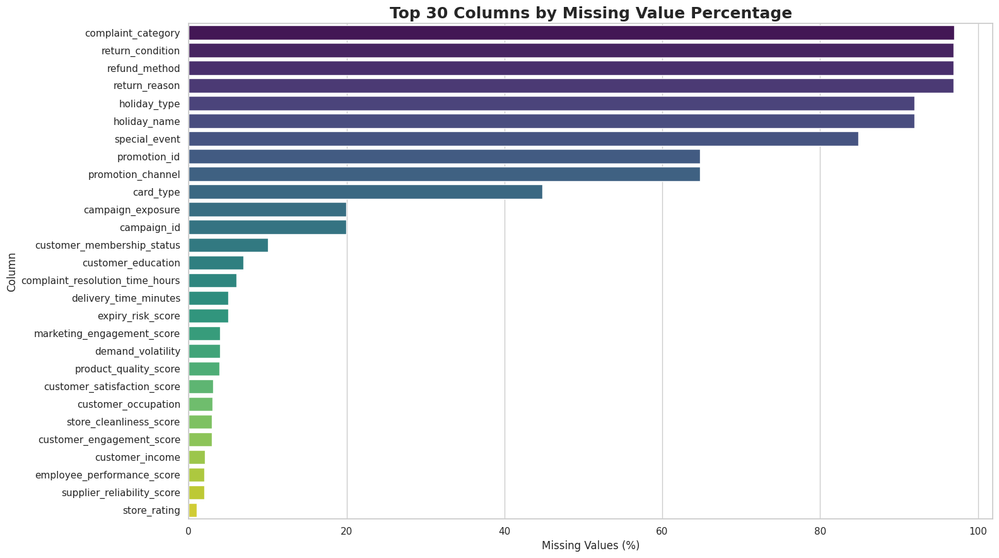


5. DUPLICATE ANALYSIS
Duplicate rows       : 0
Duplicate percentage  : 0.00%

6. NUMERIC SUMMARY


,count,mean,std,min,25%,50%,75%,max,missing,unique
customer_age,120000.0,44.787608,14.435695,18.0,35.0000,45.0000,55.0000,85.0000,0,68
customer_income,117529.0,250000.000000,0.000000,250000.0,250000.0000,250000.0000,250000.0000,250000.0000,2471,1
household_size,120000.0,3.002558,1.378411,1.0,2.0000,3.0000,4.0000,6.0000,0,6
number_of_children,120000.0,0.846308,0.860916,0.0,0.0000,1.0000,1.0000,5.0000,0,6
customer_since_year,120000.0,2016.503833,4.023941,2010.0,2013.0000,2016.0000,2020.0000,2023.0000,0,14
...,...,...,...,...,...,...,...,...,...,...
category_sales_rank,120000.0,50.528283,28.833530,1.0,25.0000,51.0000,75.0000,100.0000,0,100
product_popularity,120000.0,4.996500,1.974317,0.0,3.6000,5.0000,6.3000,10.0000,0,101
product_growth_rate,120000.0,0.050269,0.149760,-0.5,-0.0510,0.0510,0.1520,0.7240,0,1057
product_return_rate,120000.0,0.030626,0.018858,0.0,0.0166,0.0300,0.0435,0.1154,0,988



7. IMPORTANT BUSINESS COLUMNS
Revenue/Sales: ['customer_income', 'average_household_income', 'regular_price', 'selling_price', 'discount_amount', 'tax_amount', 'final_unit_price', 'wholesale_price', 'supplier_price', 'price_index', 'competitor_price', 'price_difference_from_competitor', 'unit_price', 'gross_sales', 'net_sales', 'total_amount', 'average_item_price', 'inventory_turnover_rate', 'price_sensitivity_score', 'sales_channel', 'refund_amount', 'competitor_average_price', 'relative_price_index', 'local_average_income', 'food_price_index', 'sales_revenue', 'sales_rank', 'category_sales_rank']
Profit: ['gross_profit', 'profit_margin_percent', 'profit_per_unit', 'profit_margin']
Quantity: ['number_of_checkout_counters', 'number_of_self_checkout_counters', 'country', 'nearby_competitor_count', 'package_quantity', 'country_of_origin', 'discount_amount', 'discount_percent', 'quantity', 'average_discount_percent', 'premium_product_count', 'budget_product_count', 'impulse_purchase_coun

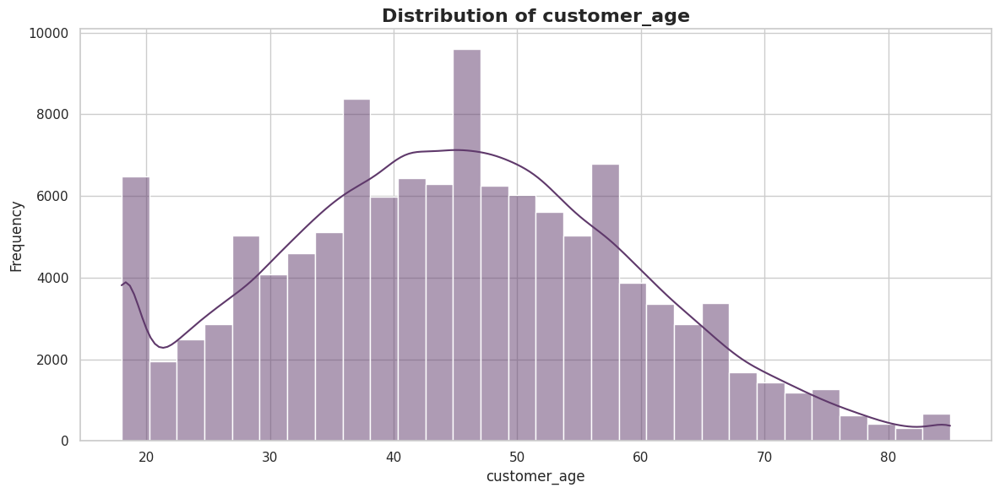

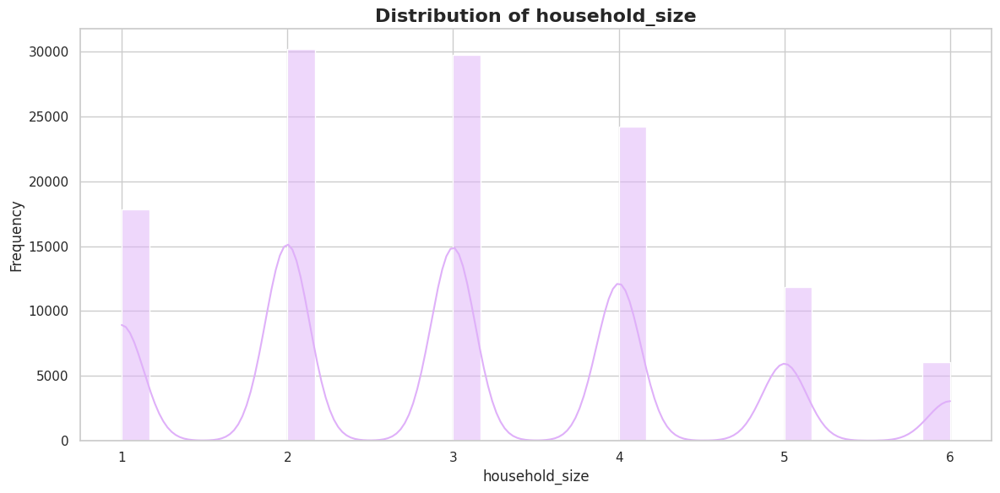

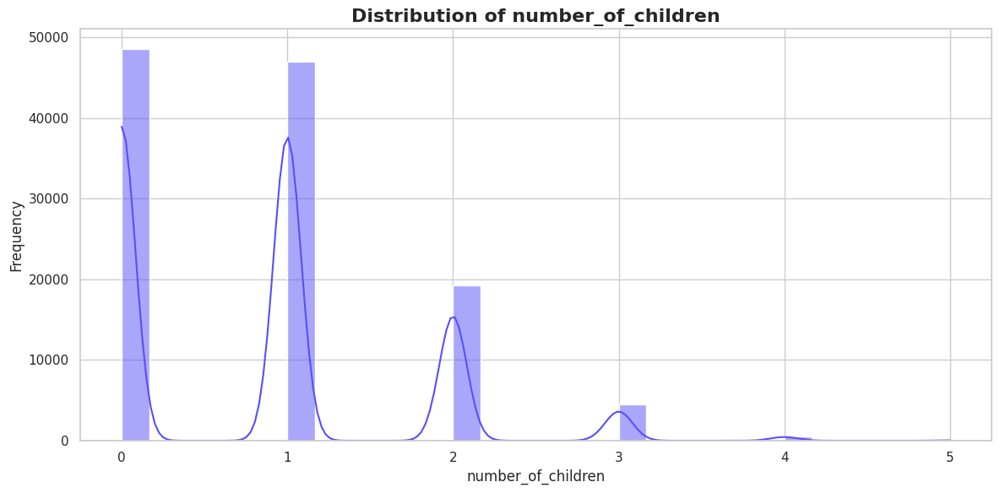

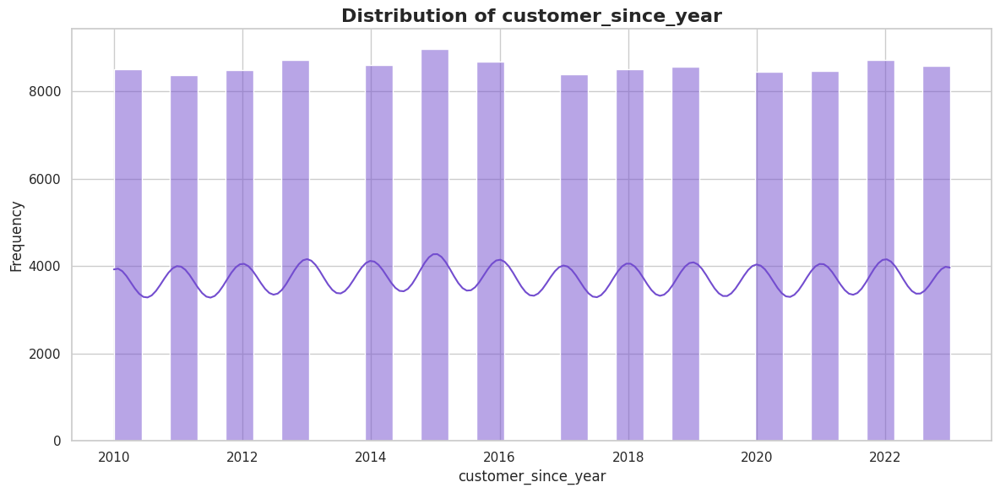

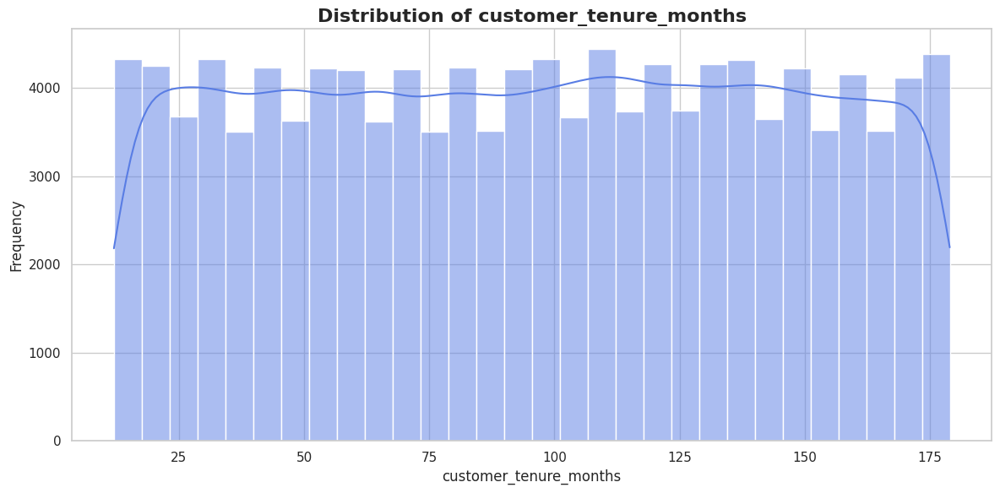

...

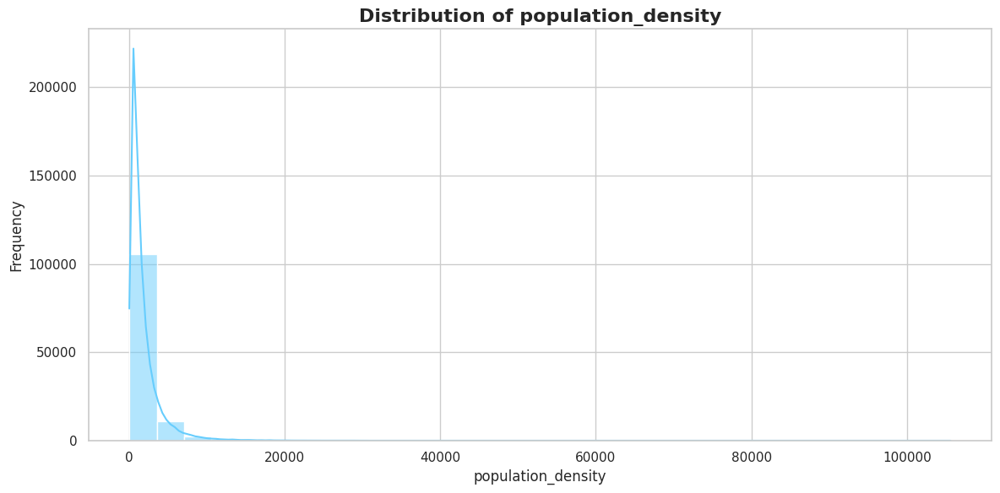

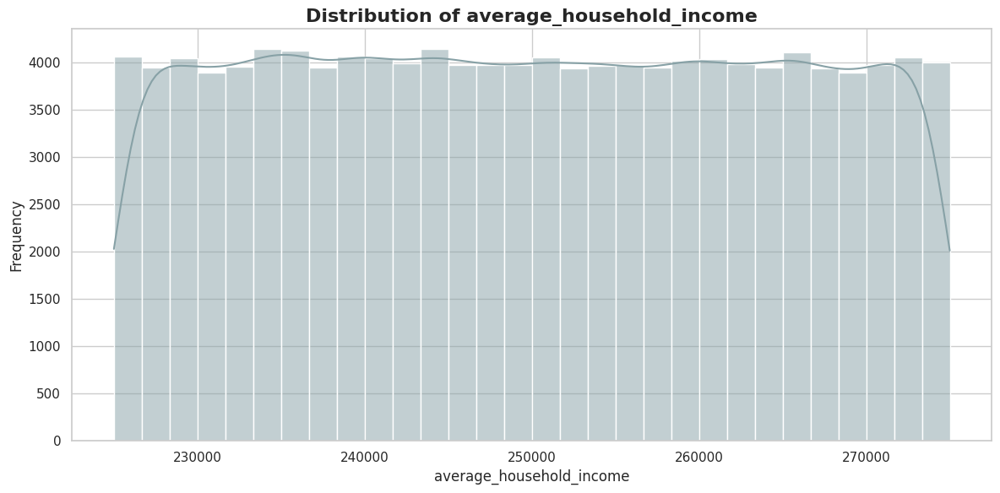

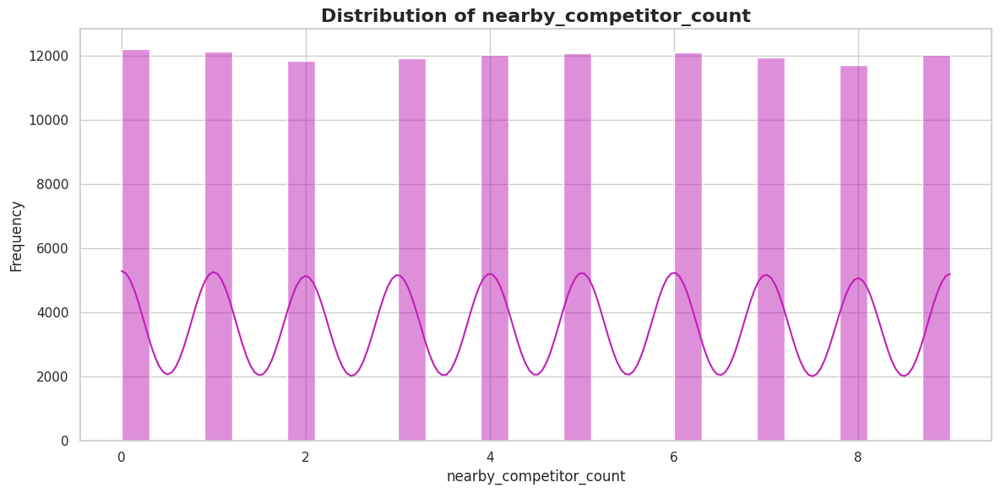

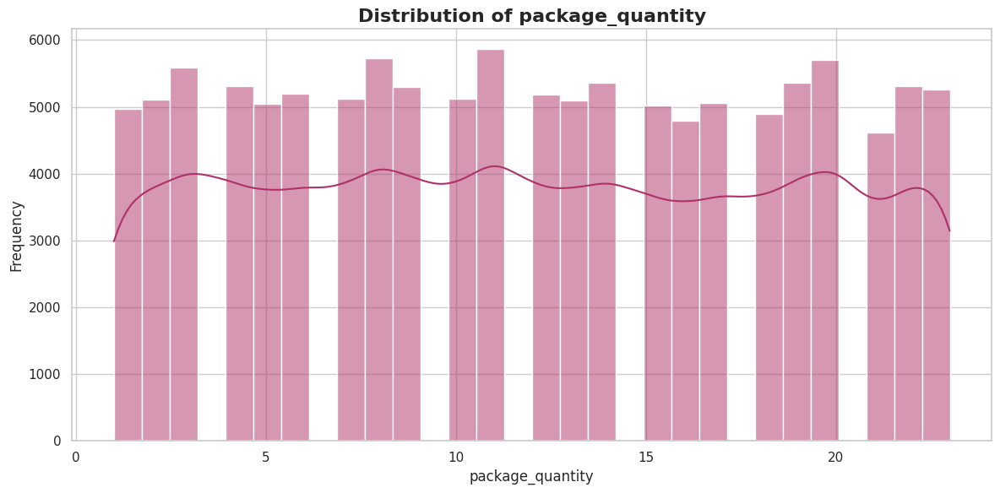

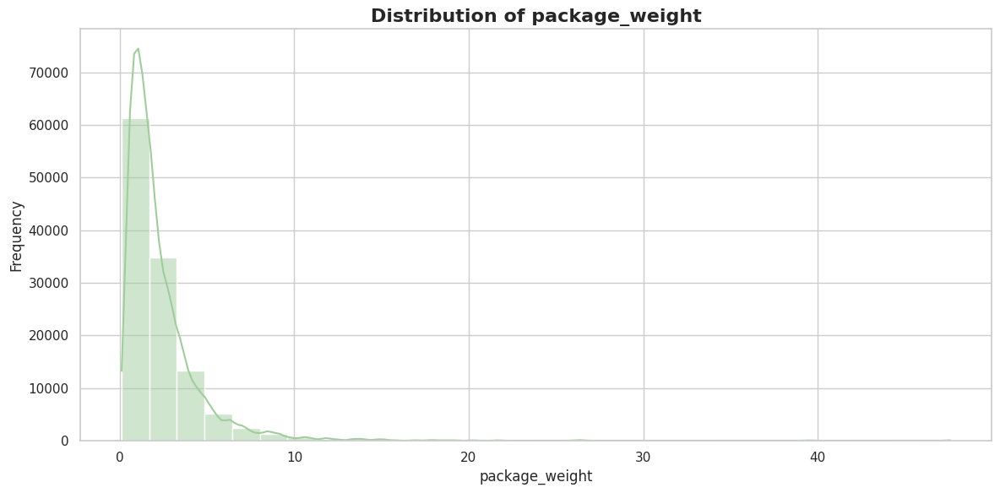


9. OUTLIER ANALYSIS


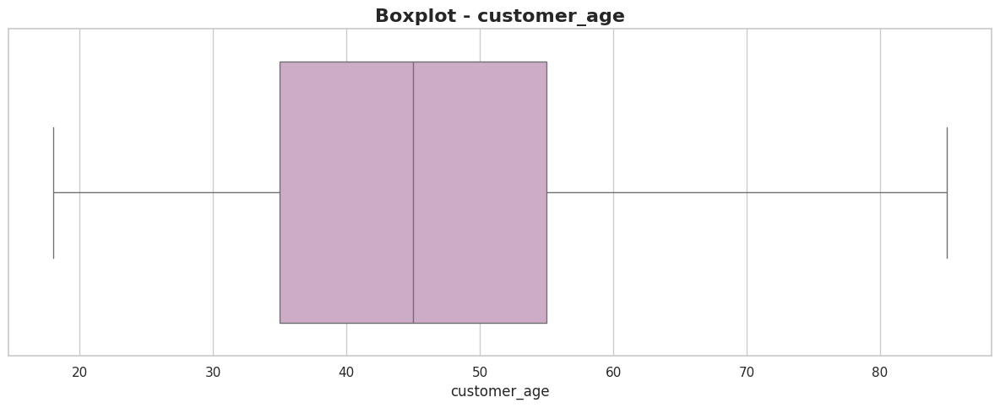

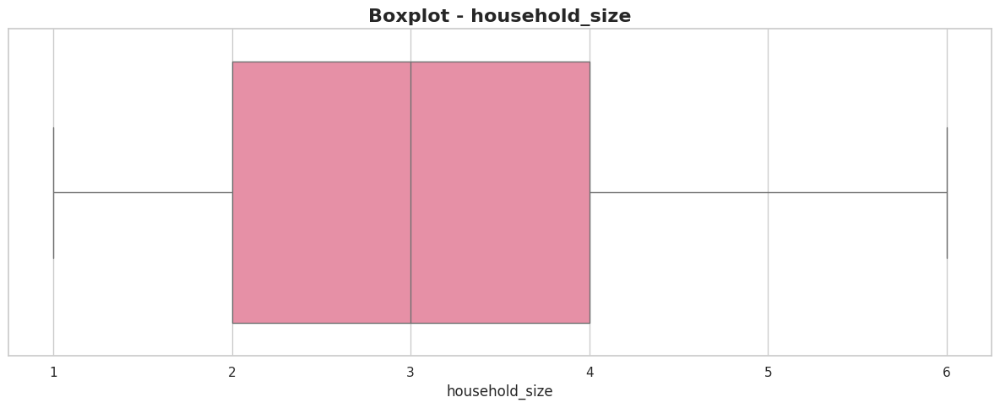

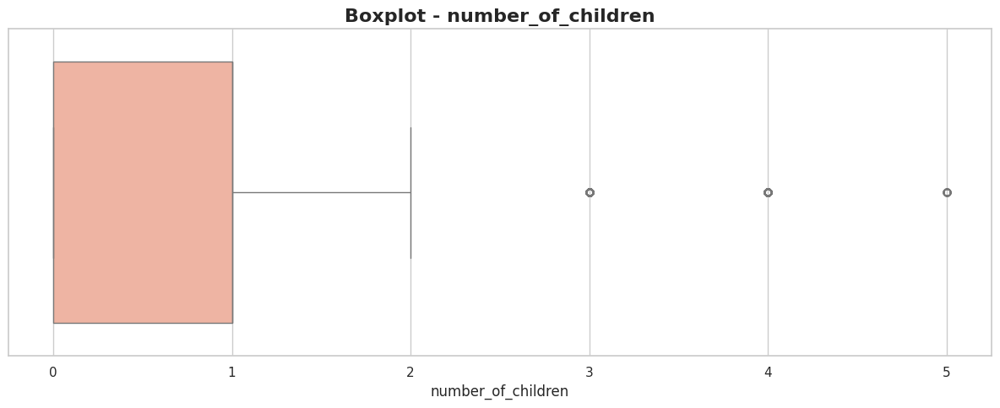

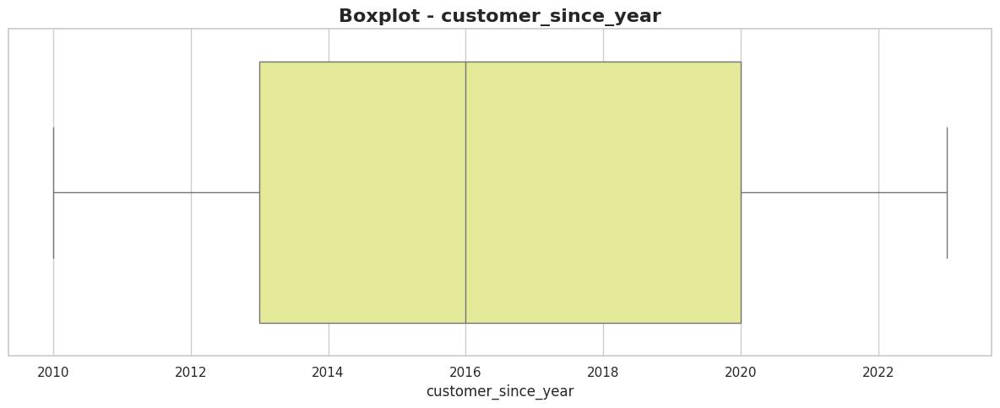

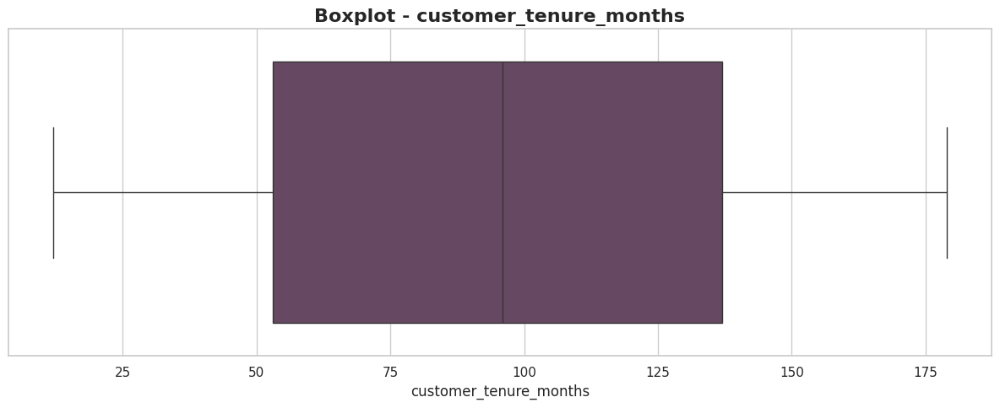

...

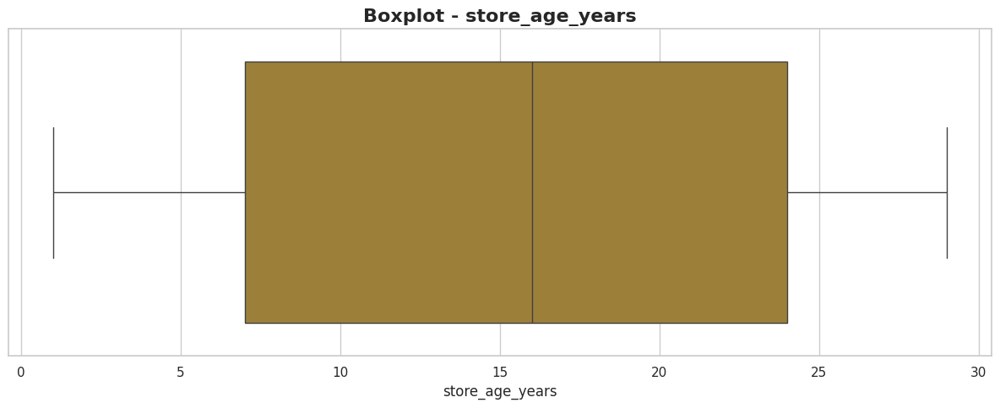

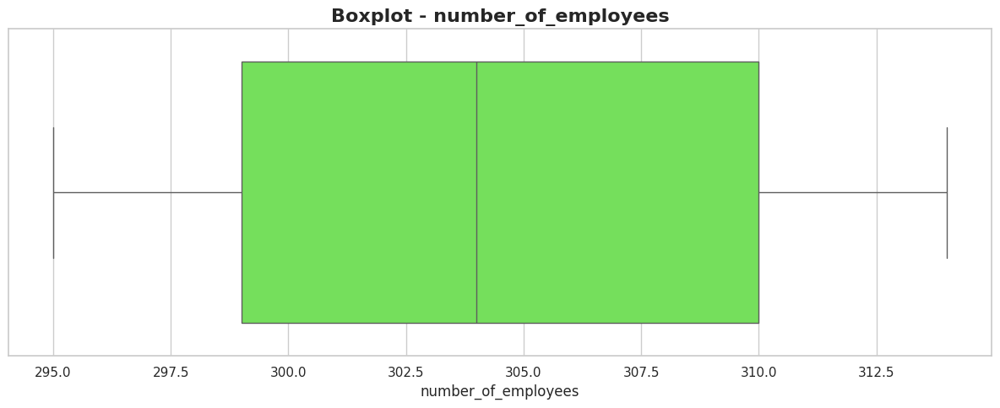

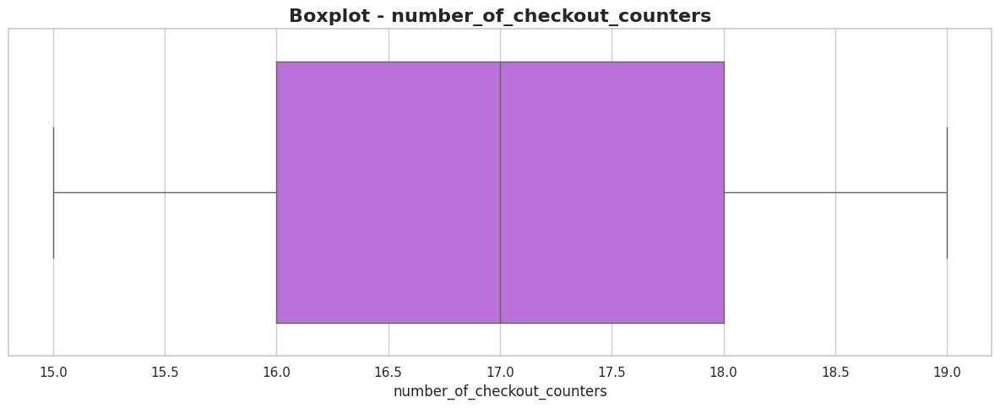

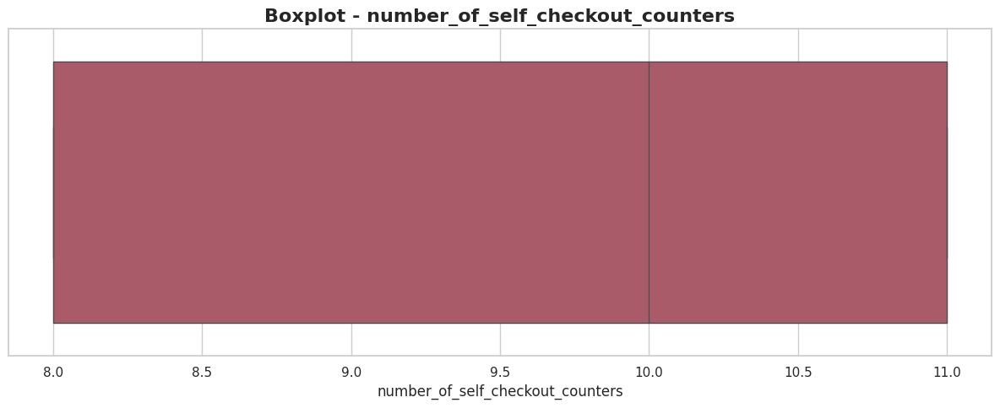

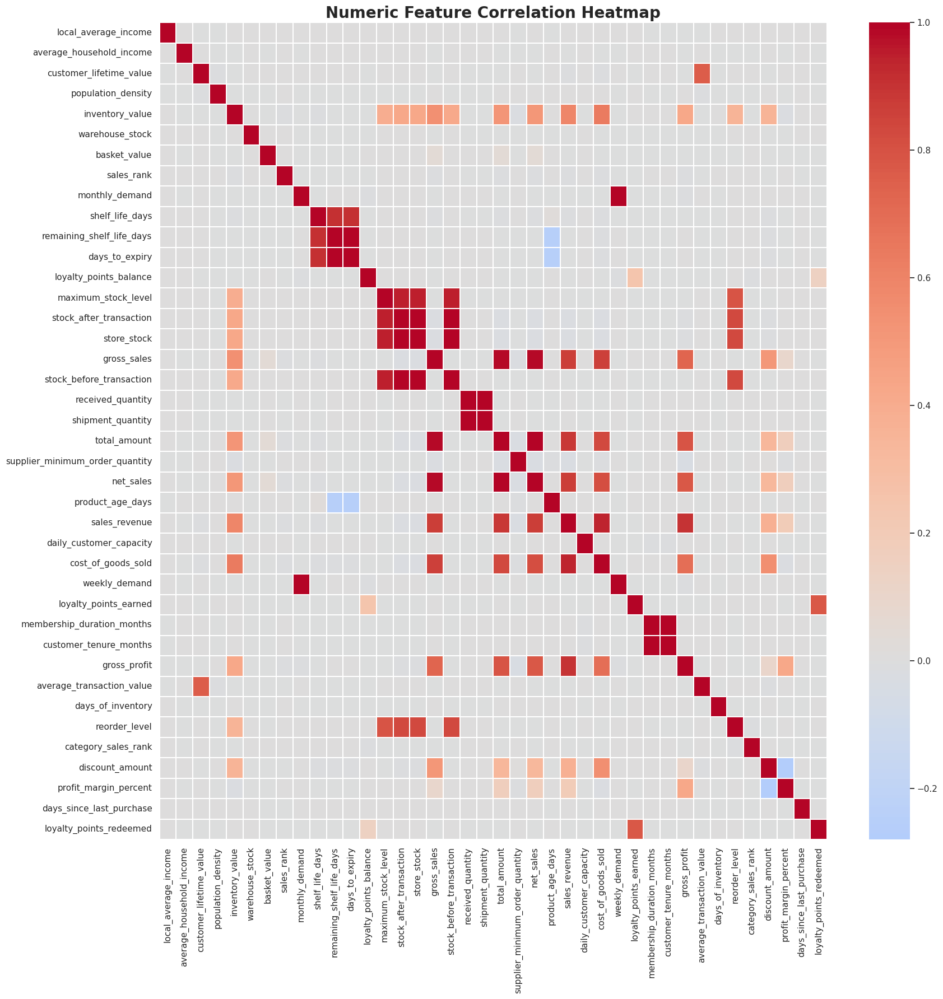


10. TOP 30 CORRELATED FEATURE PAIRS


,Feature_1,Feature_2,Correlation,Absolute_Correlation
12256,daily_demand,monthly_demand,1.000000,1.000000
12336,weekly_demand,monthly_demand,1.000000,1.000000
14400,planned_purchase_ratio,impulse_purchase_ratio,-1.000000,1.000000
12255,daily_demand,weekly_demand,1.000000,1.000000
1548,customer_visit_frequency,average_monthly_visits,1.000000,1.000000
8674,number_of_items,items_per_transaction,1.000000,1.000000
11471,quantity_sold,units_sold,1.000000,1.000000
4529,nearby_competitor_count,competitor_count,1.000000,1.000000
11488,stock_after_transaction,store_stock,1.000000,1.000000
8791,number_of_unique_products,unique_categories_in_basket,1.000000,1.000000


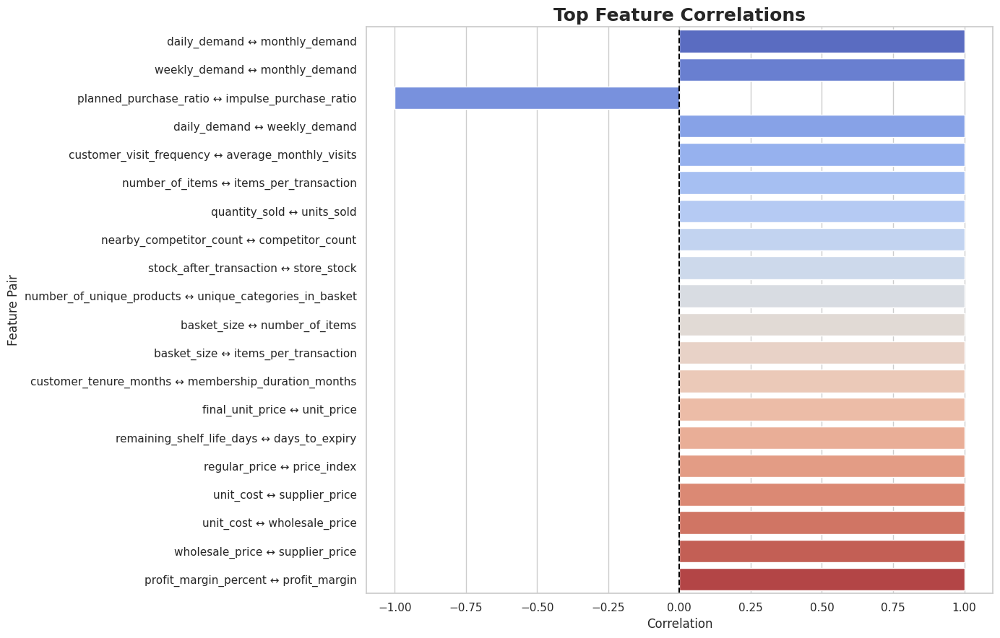


11. CATEGORICAL COLUMNS
['customer_gender', 'customer_marital_status', 'customer_education', 'customer_occupation', 'customer_segment', 'customer_region', 'customer_city', 'customer_area_type', 'urban_rural', 'customer_membership_status', 'membership_tier', 'loyalty_program_member', 'loyalty_tier', 'store_type', 'store_format', 'store_region', 'store_city', 'store_area_type', 'store_operational_status', 'region', 'state_province', 'city', 'district', 'neighborhood_type', 'shopping_center_presence']


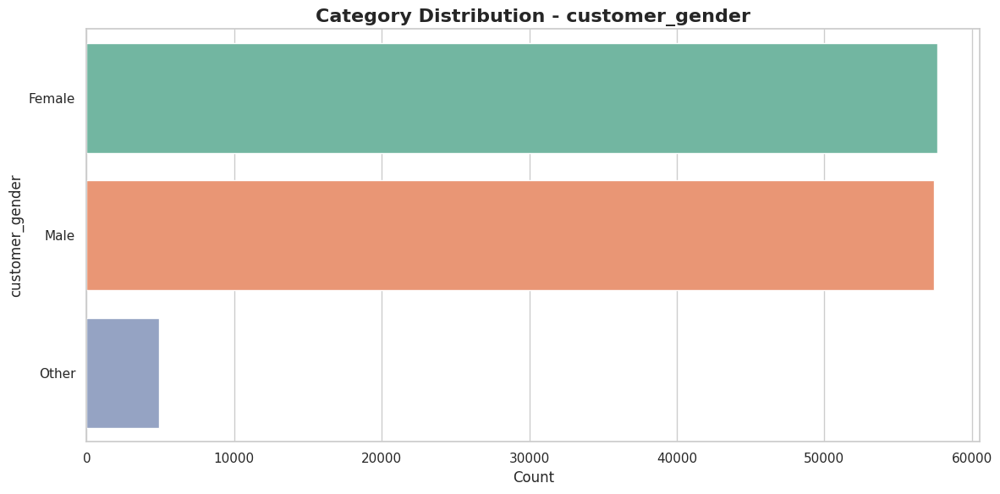

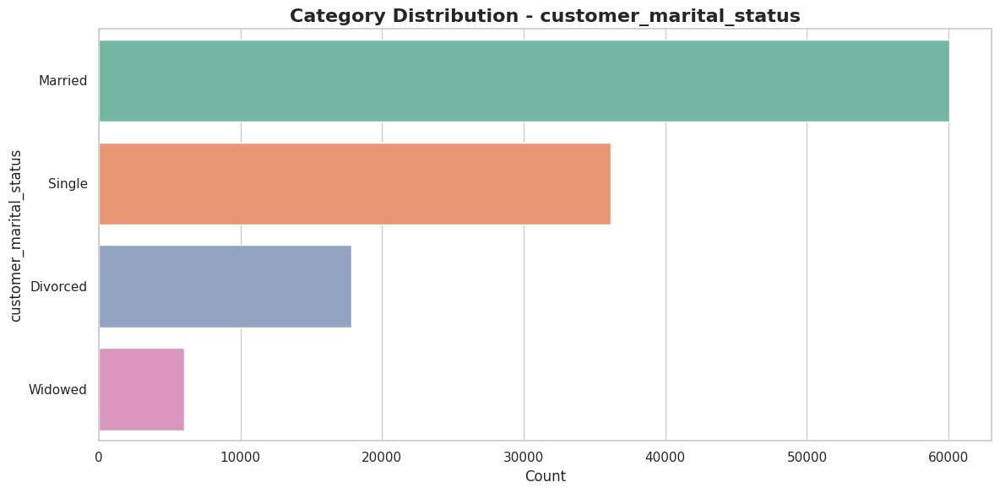

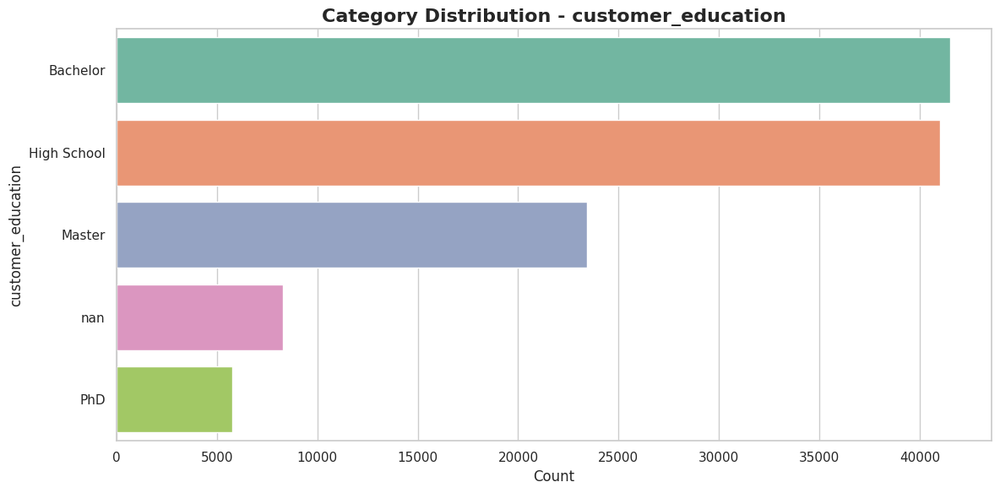

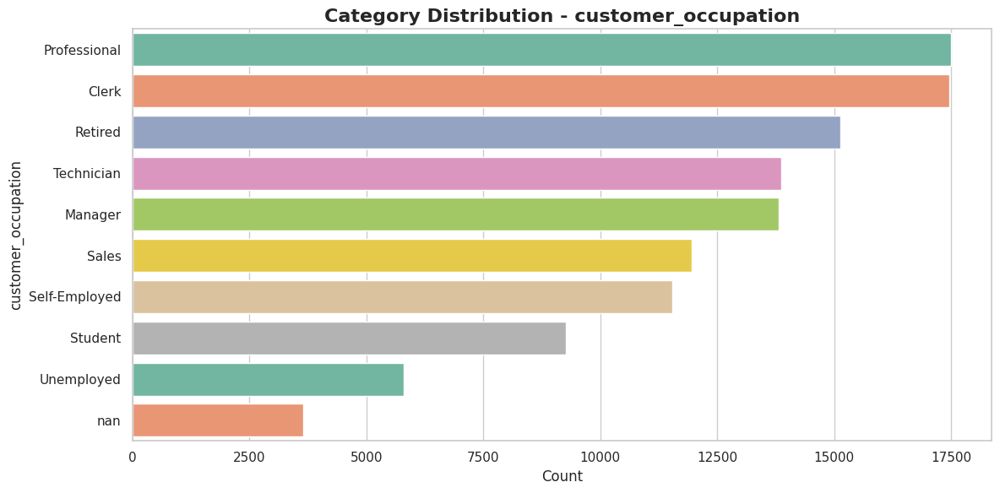

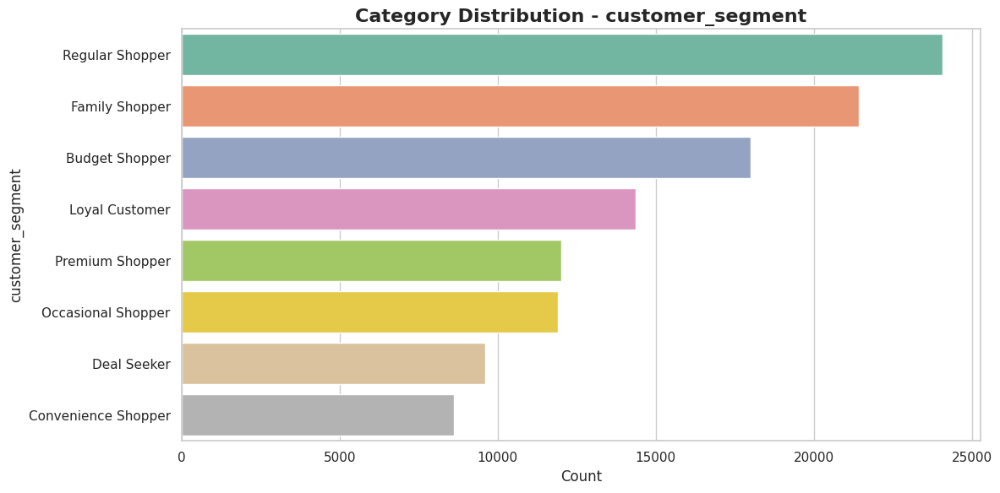

...

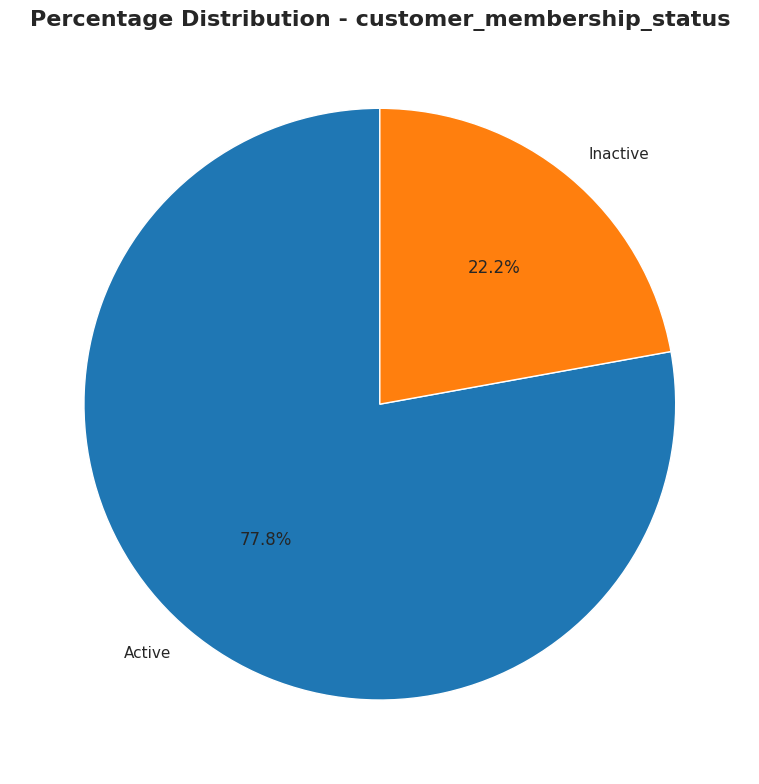

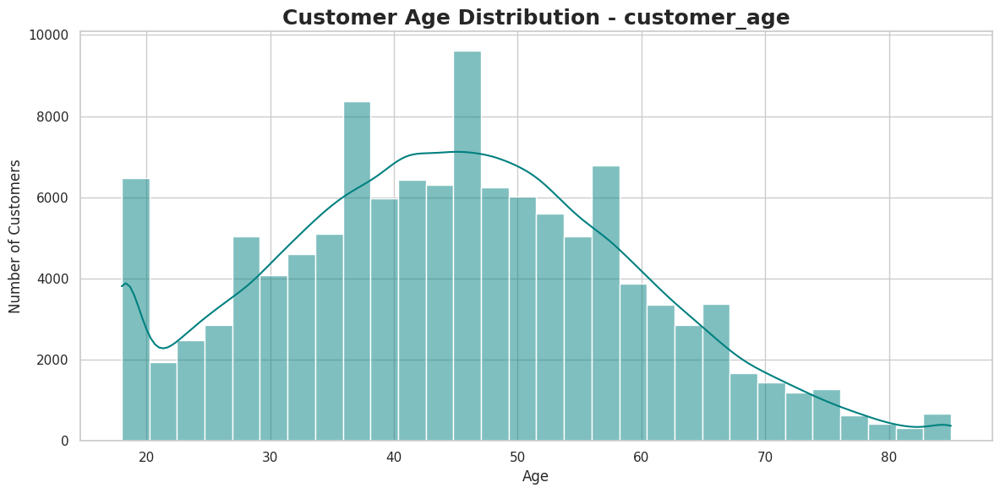

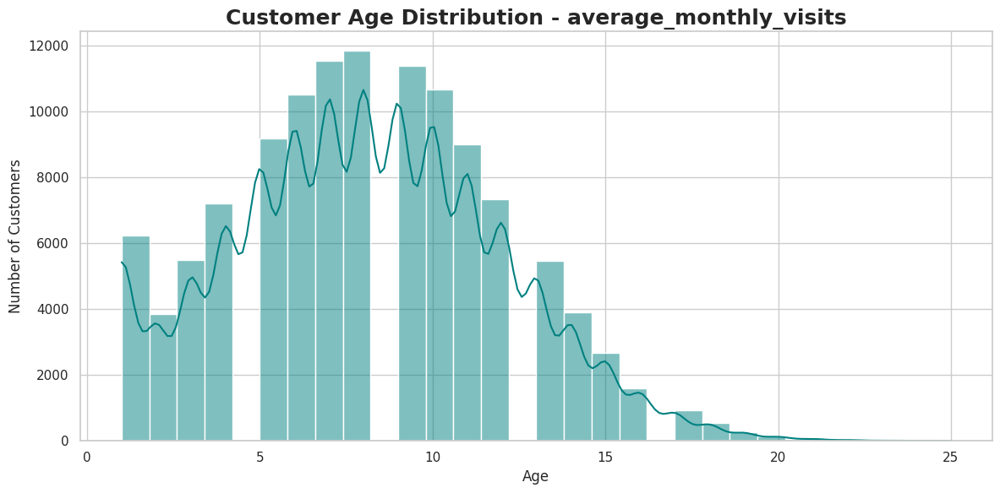

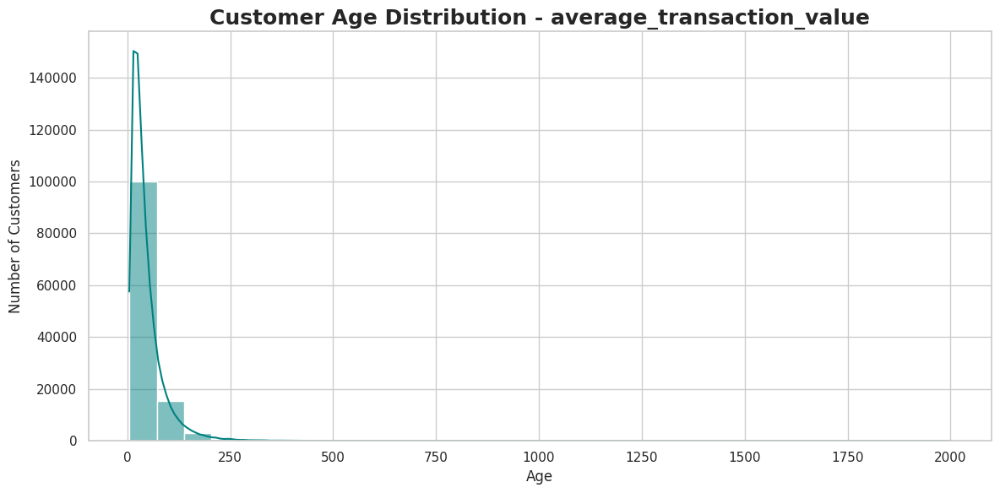

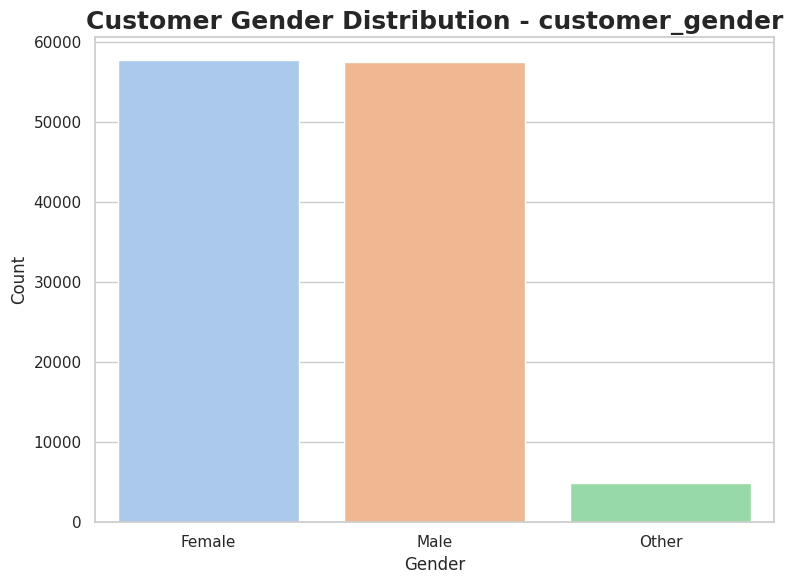


12. SALES / REVENUE VISUALIZATION


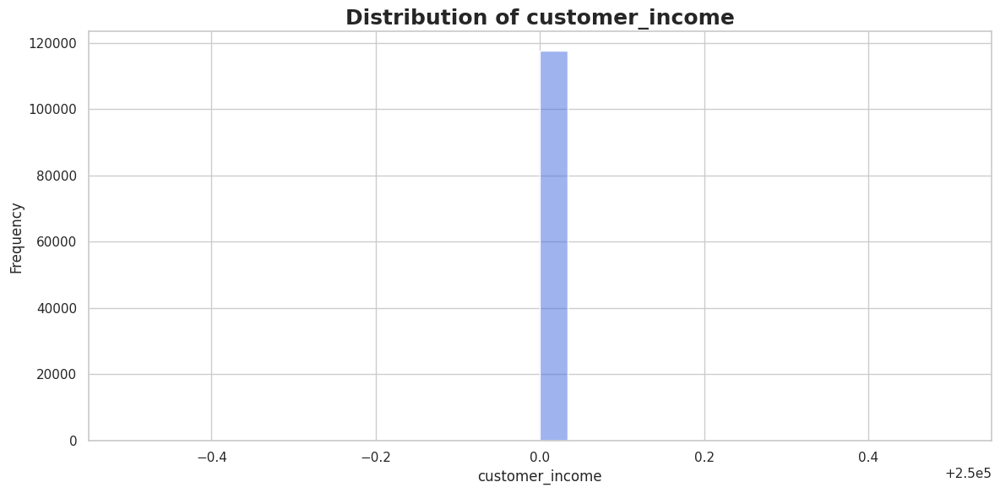

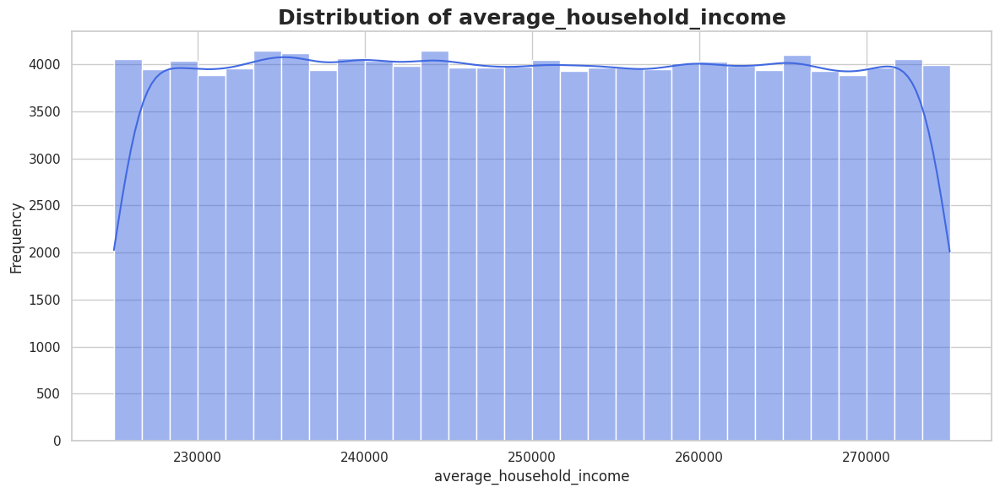

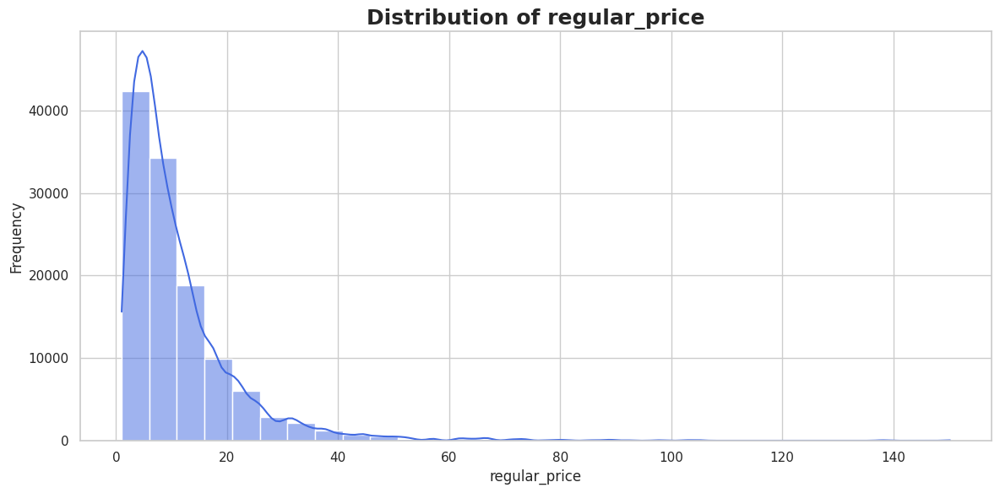

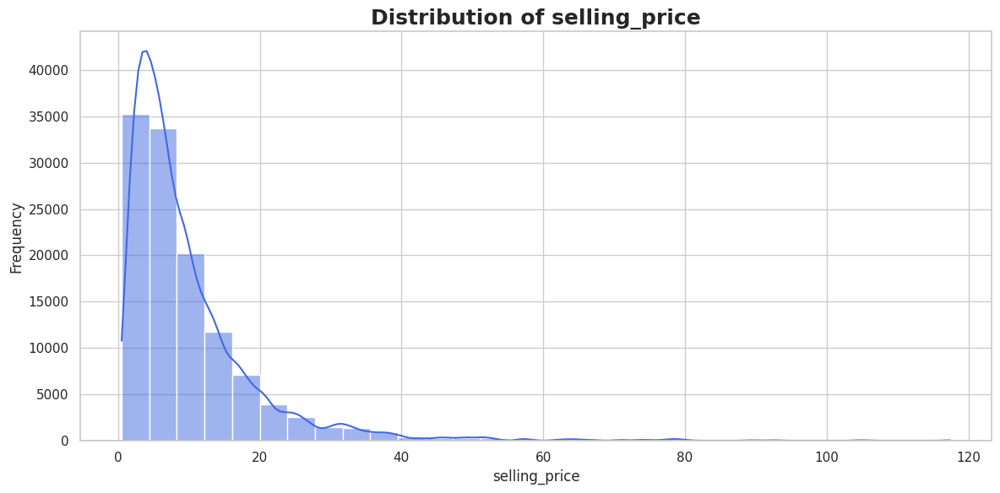

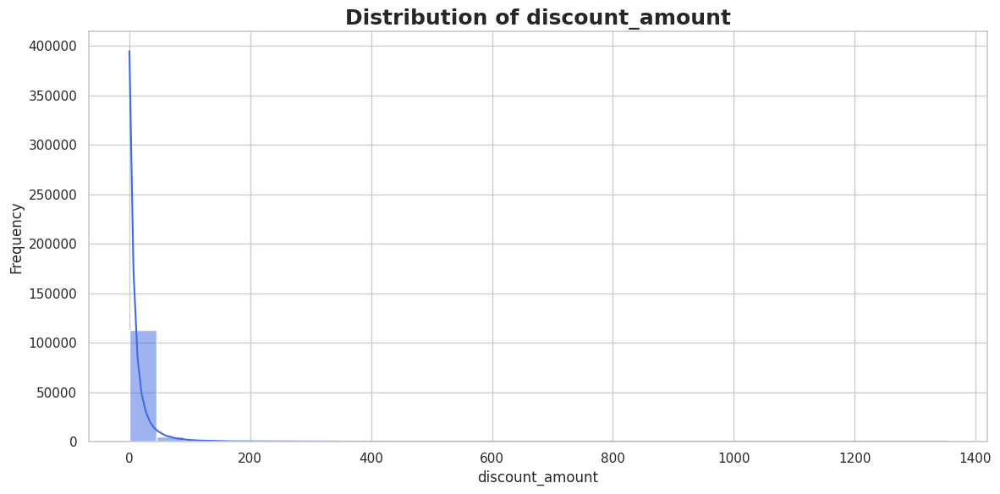

...

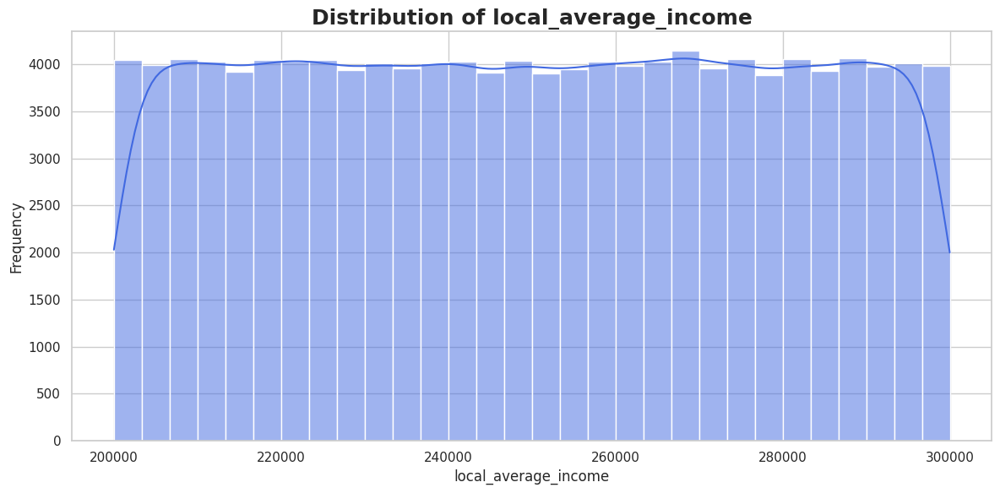

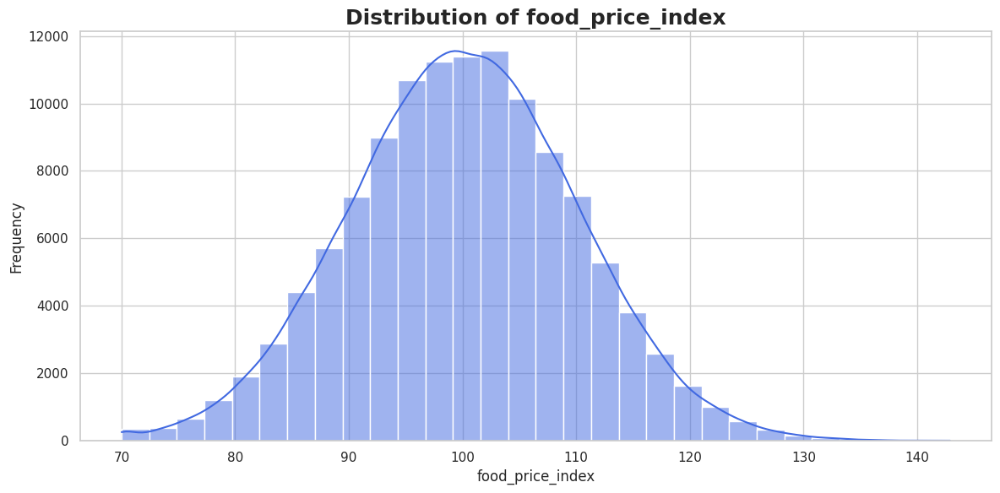

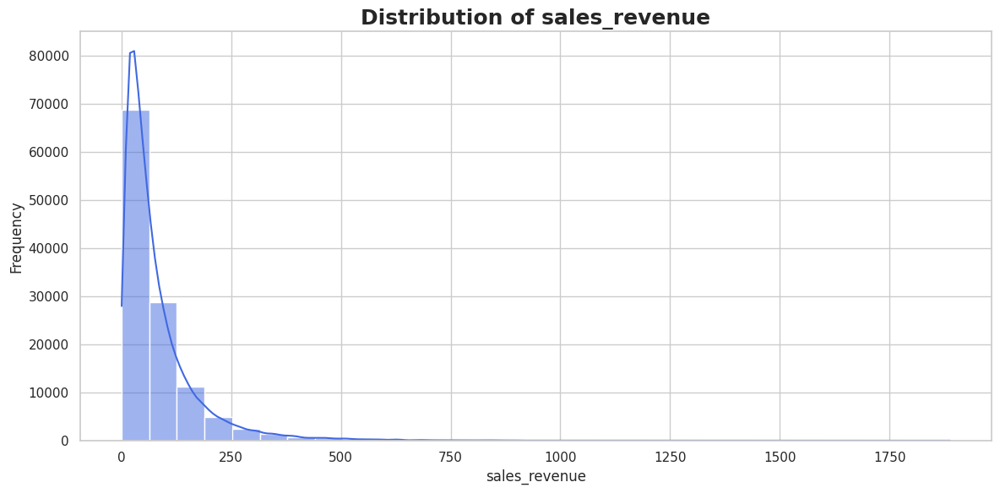

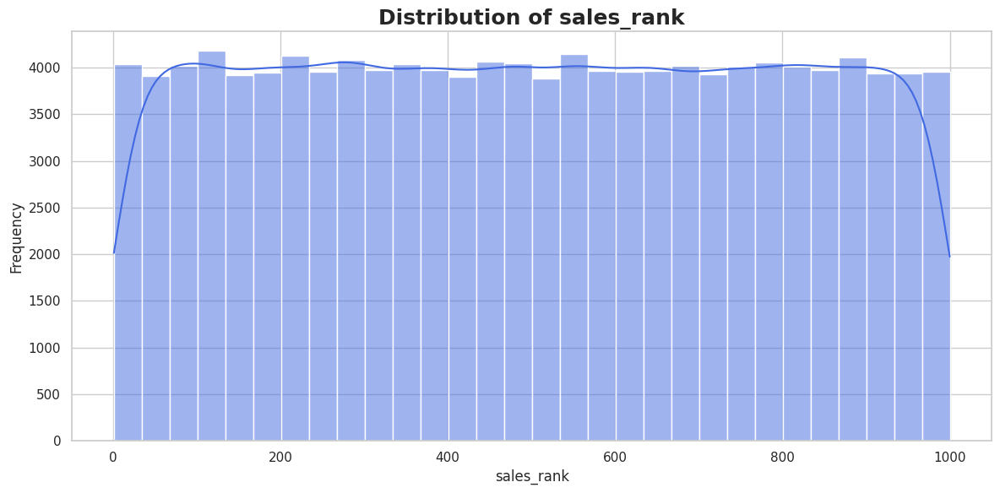

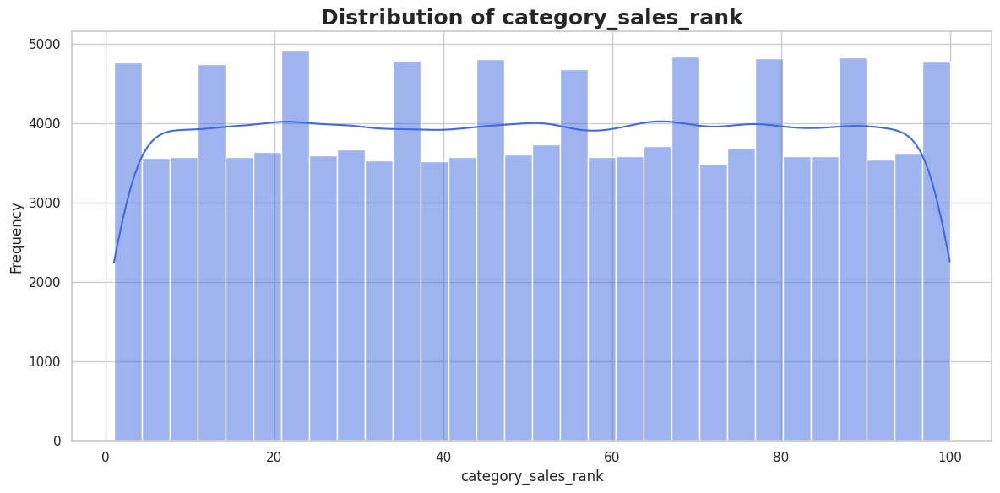


13. PROFIT VISUALIZATION


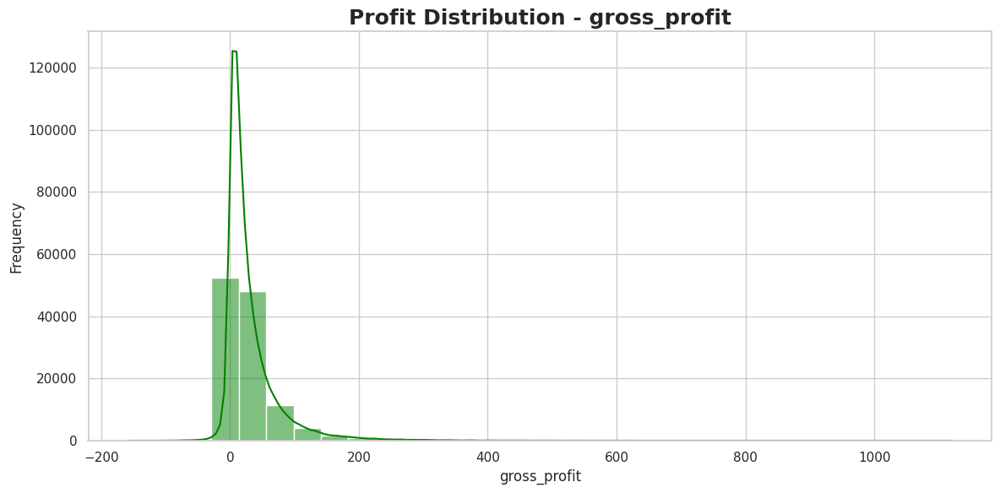

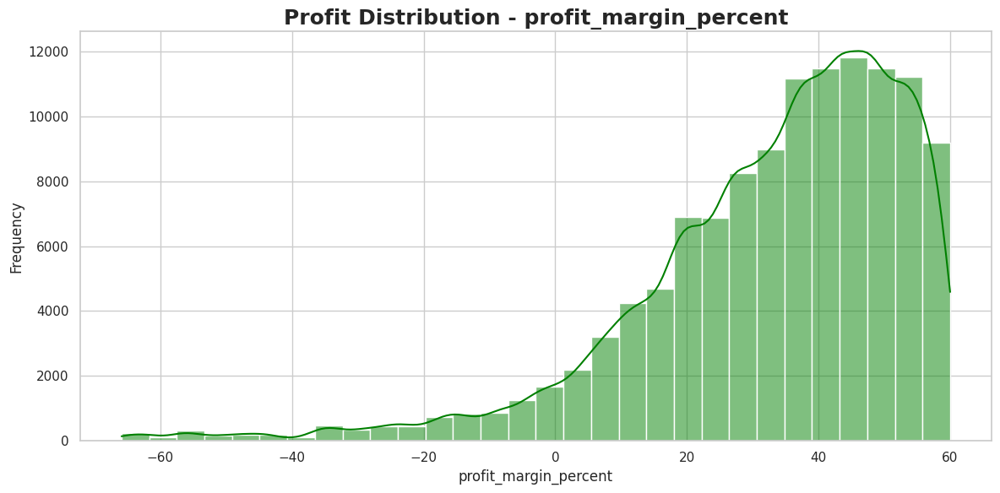

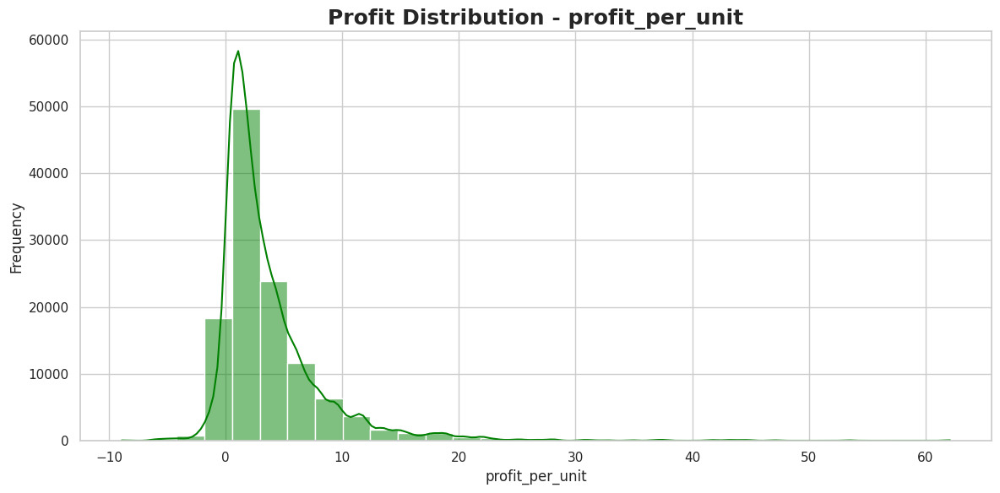

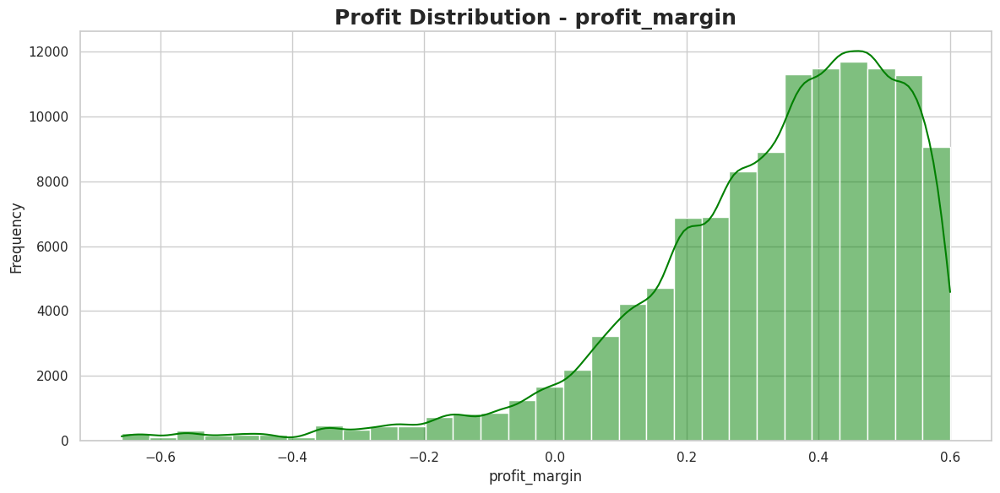

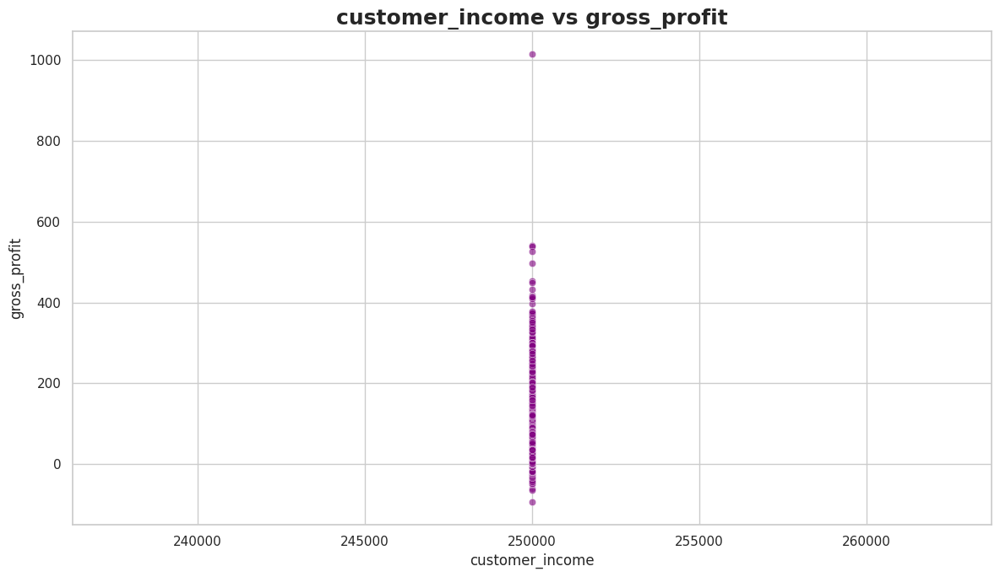

...

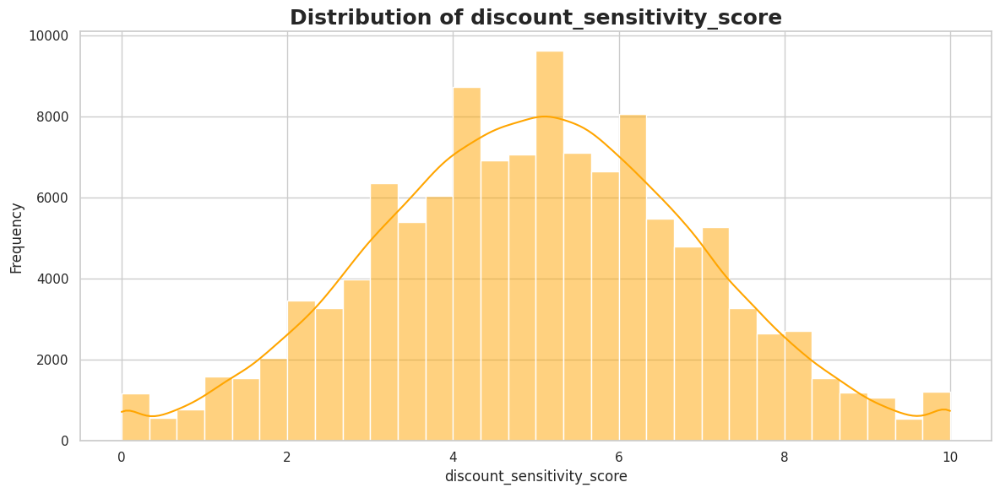

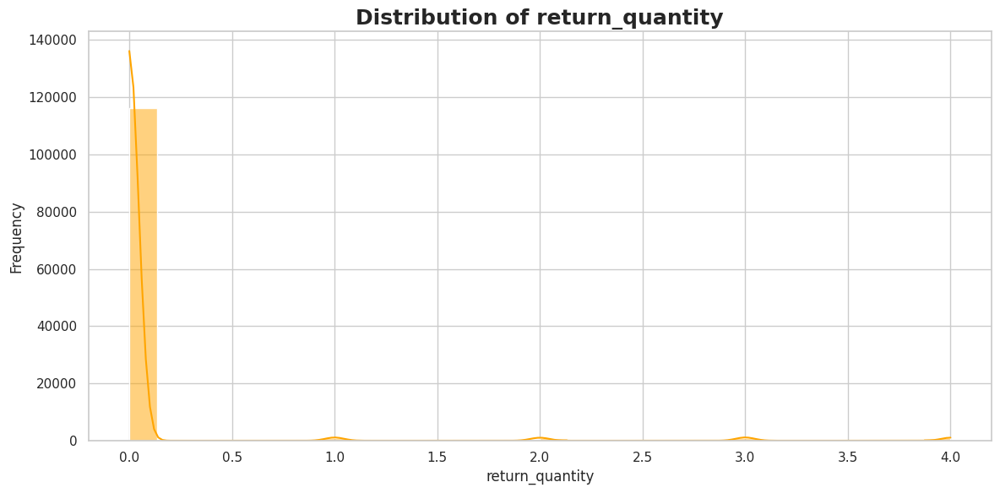

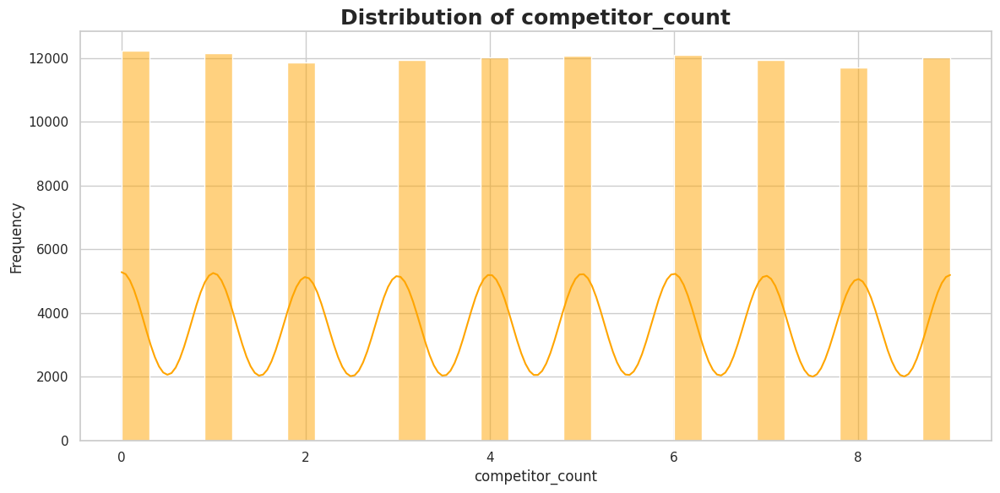

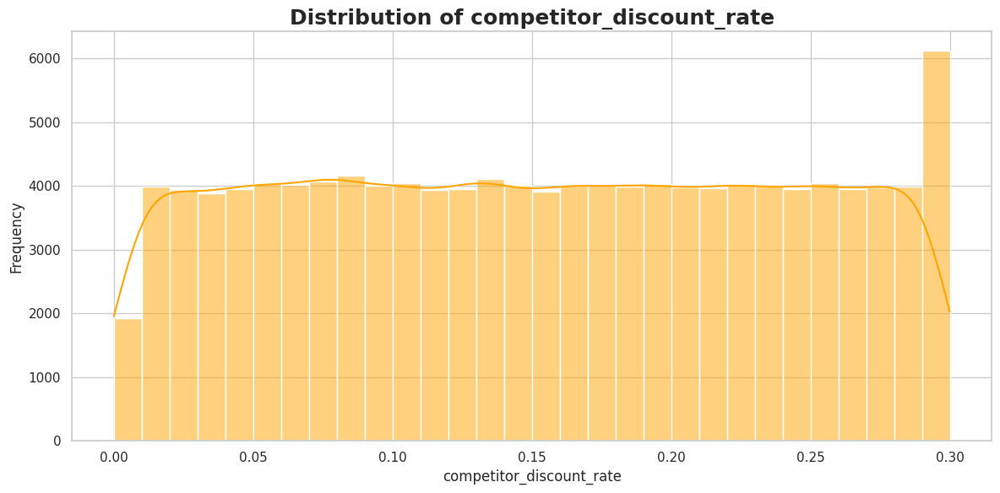

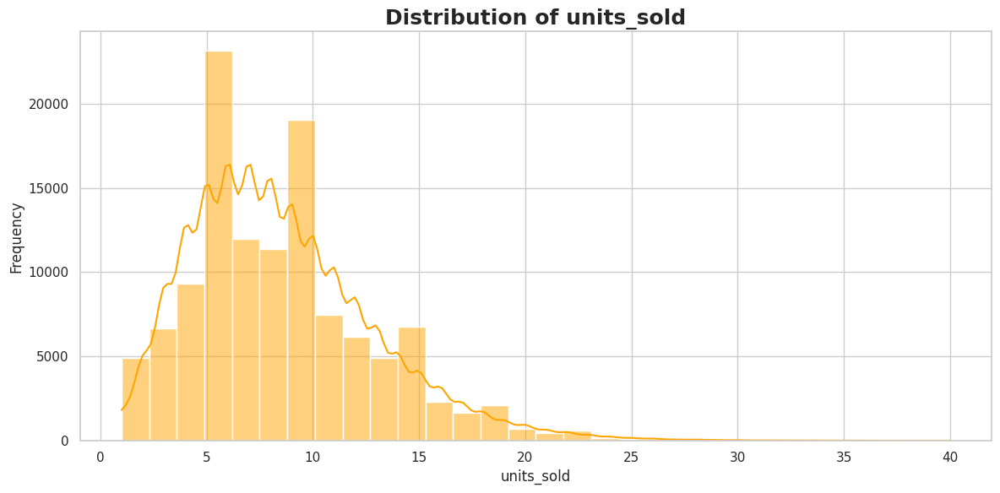


Popularity / ranking columns:
['product_popularity_score', 'demand_growth_rate', 'return_rate', 'sales_rank', 'category_sales_rank', 'product_popularity', 'product_growth_rate', 'product_return_rate', 'product_stockout_rate']


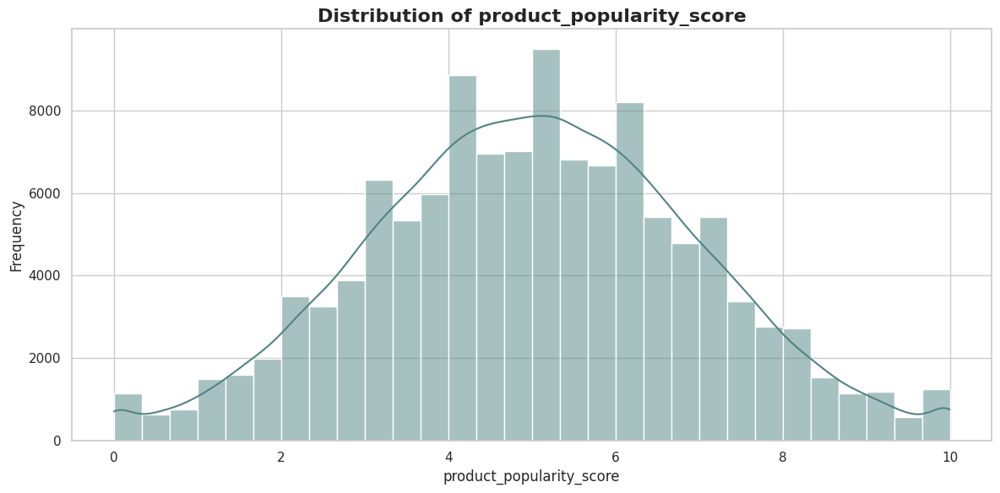

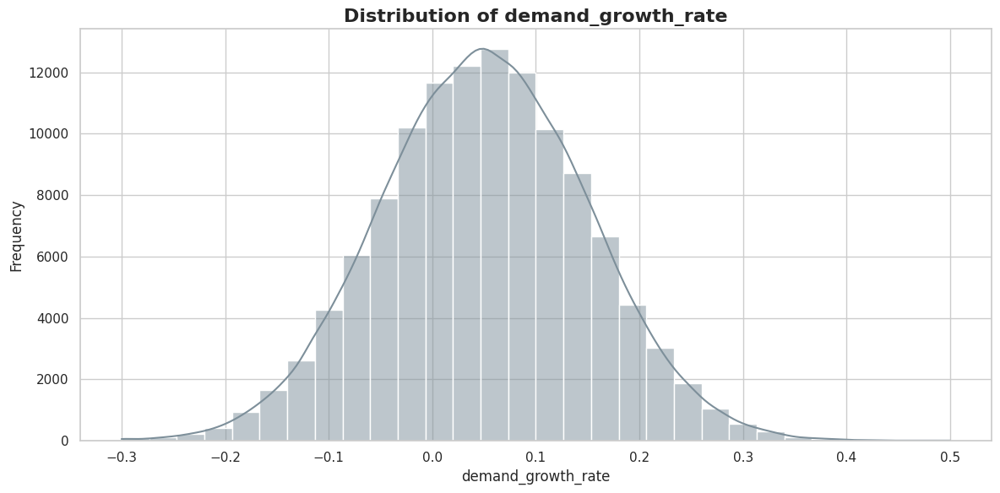

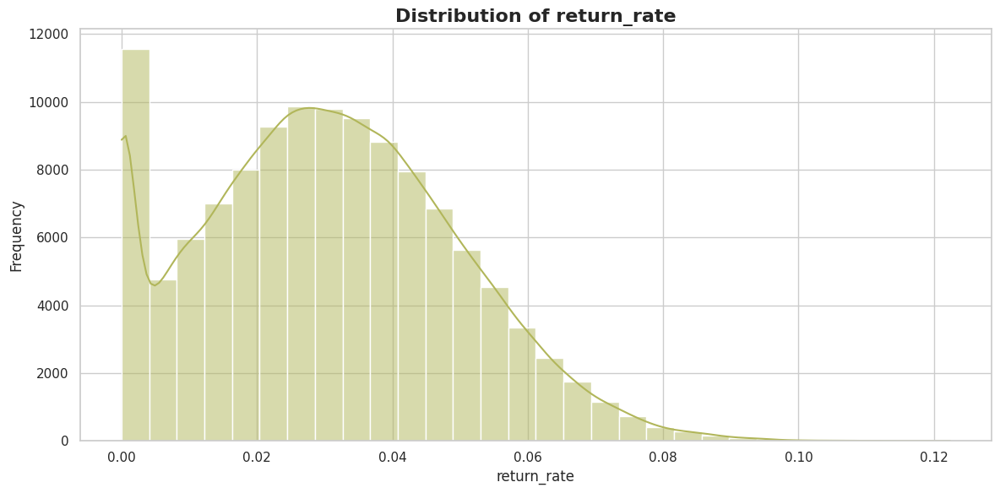

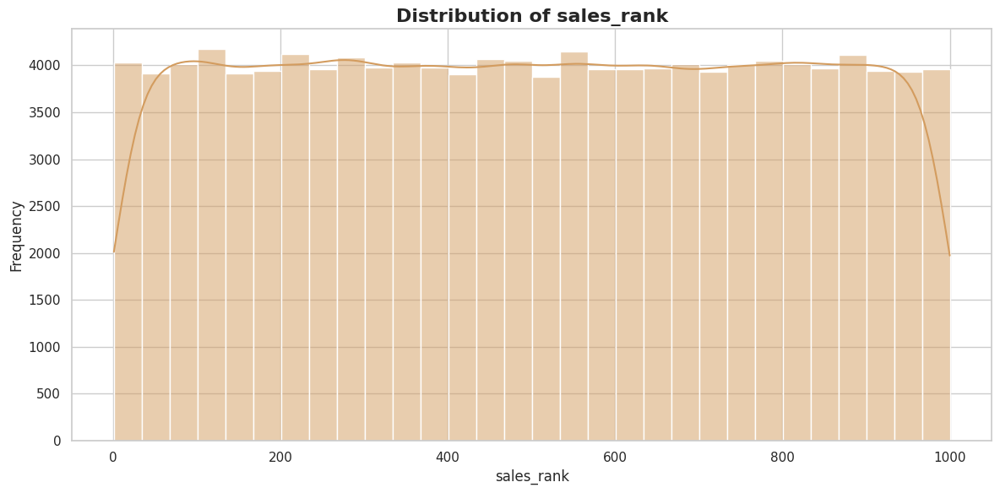

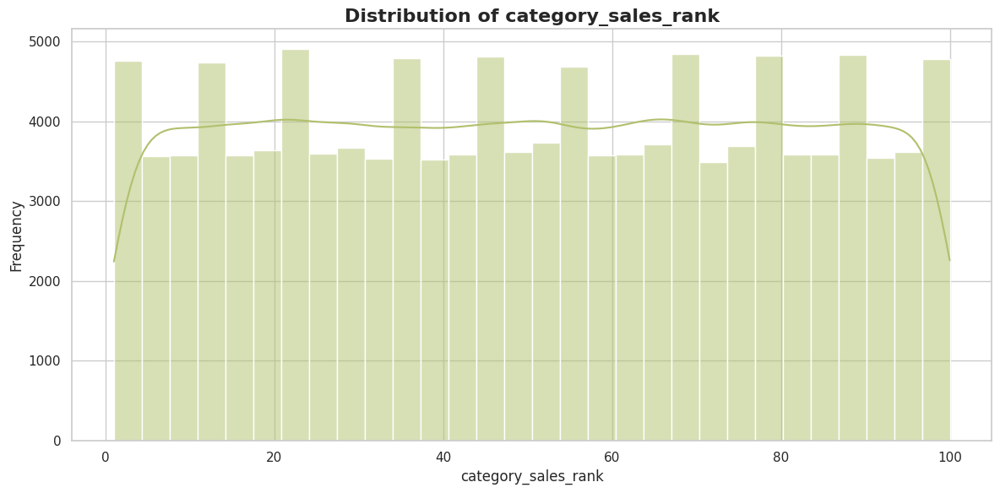

...

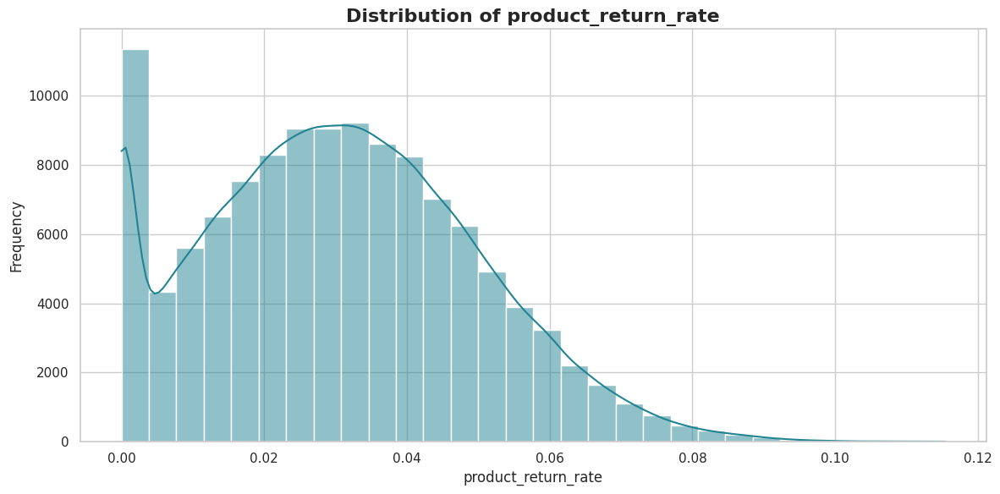

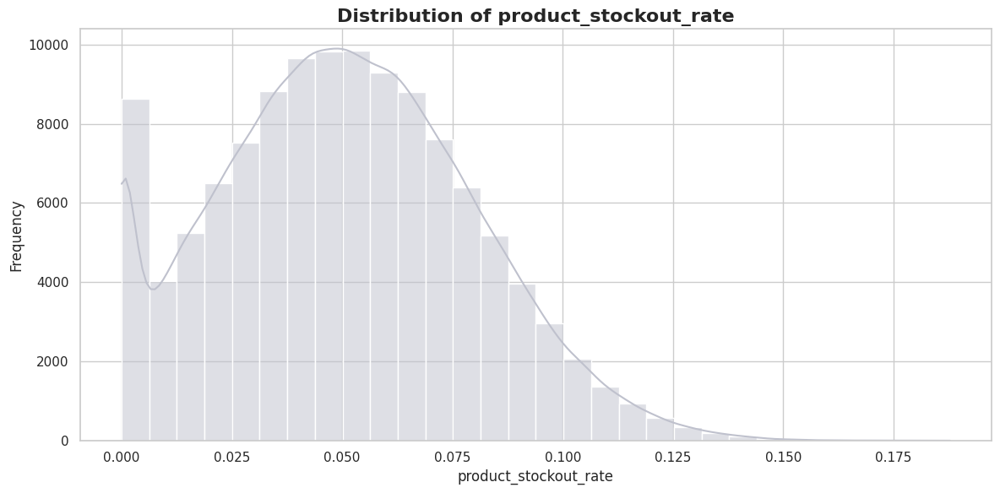

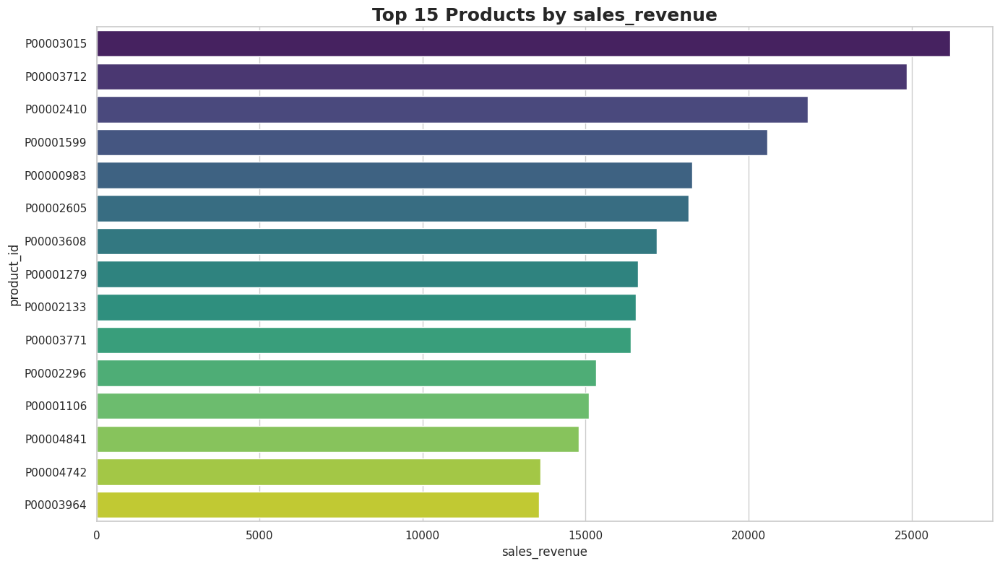

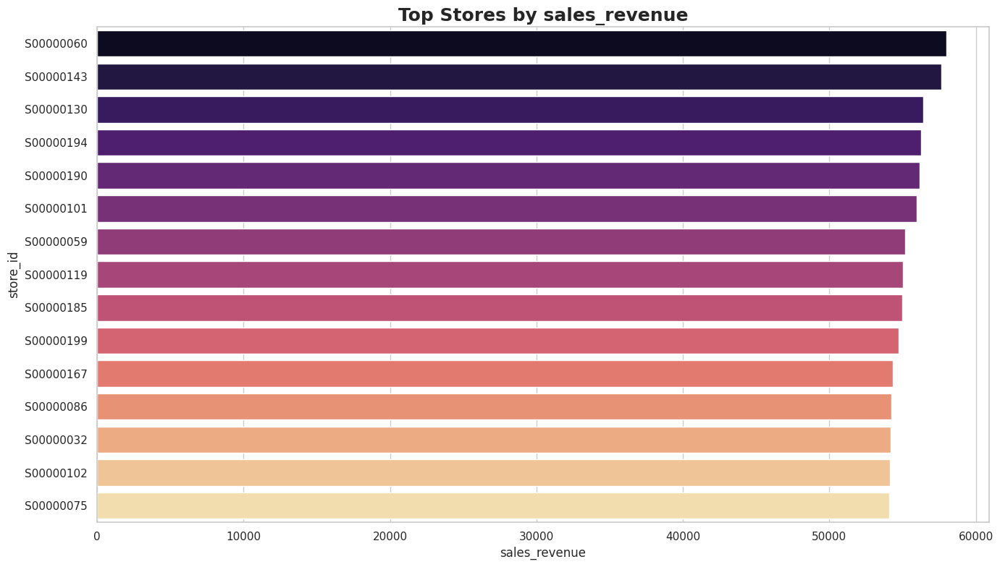

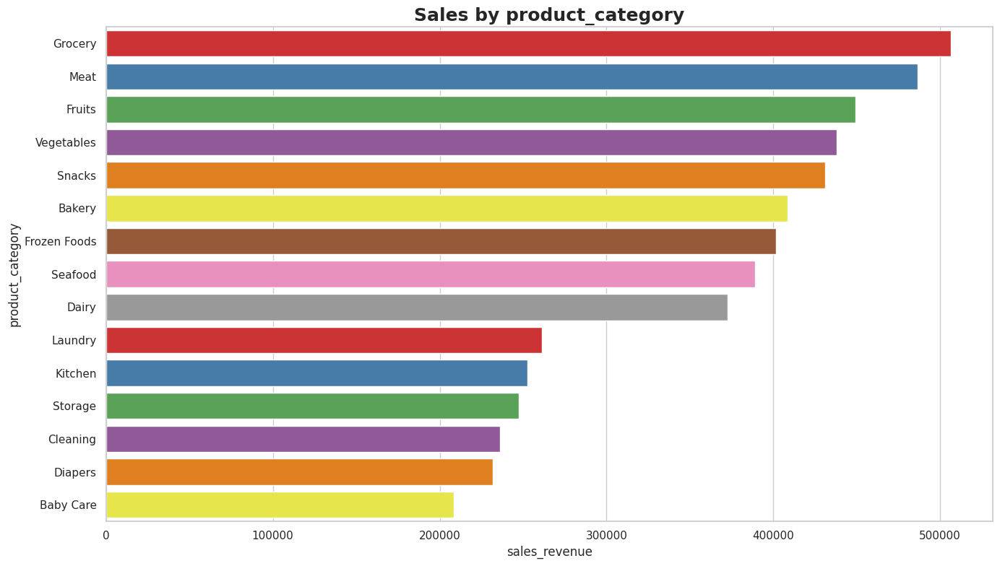


14. TIME SERIES ANALYSIS
Using date column: transaction_date


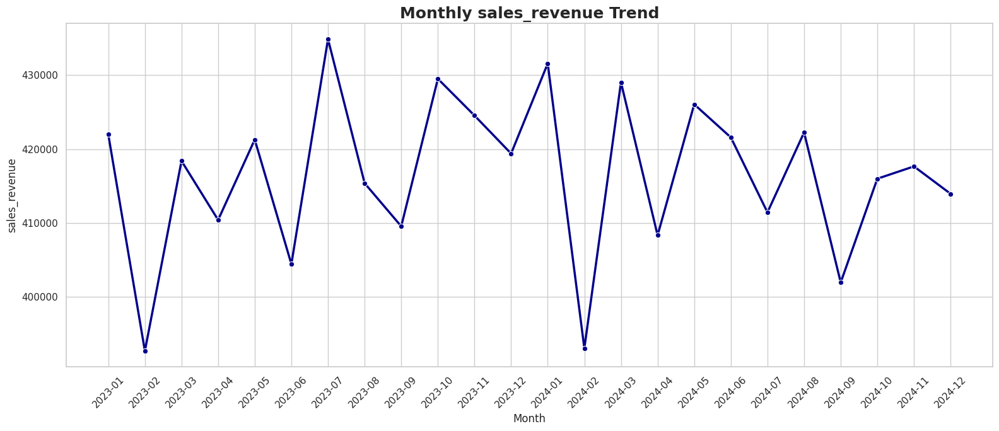

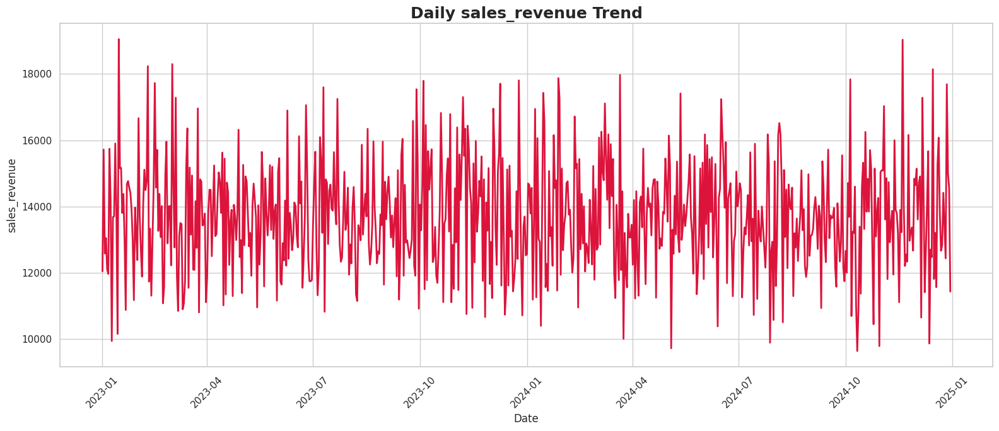

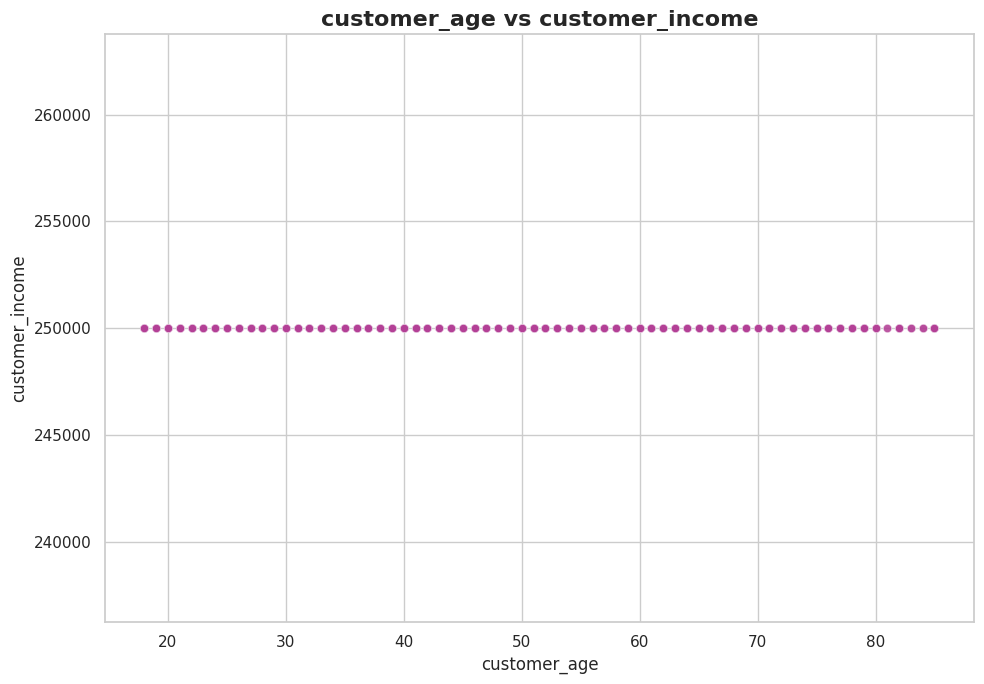

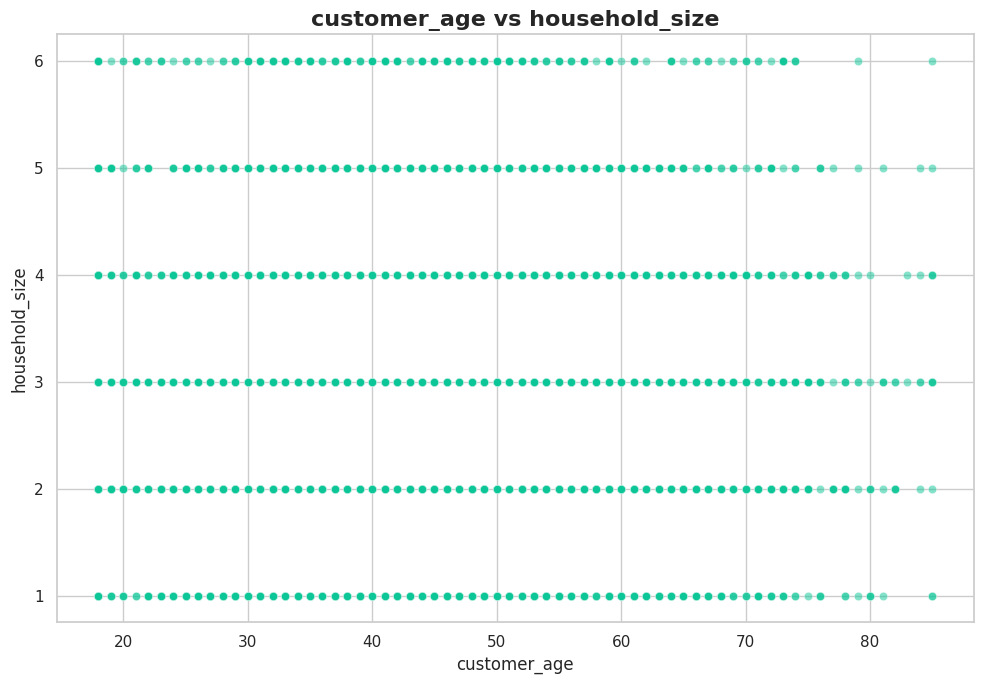

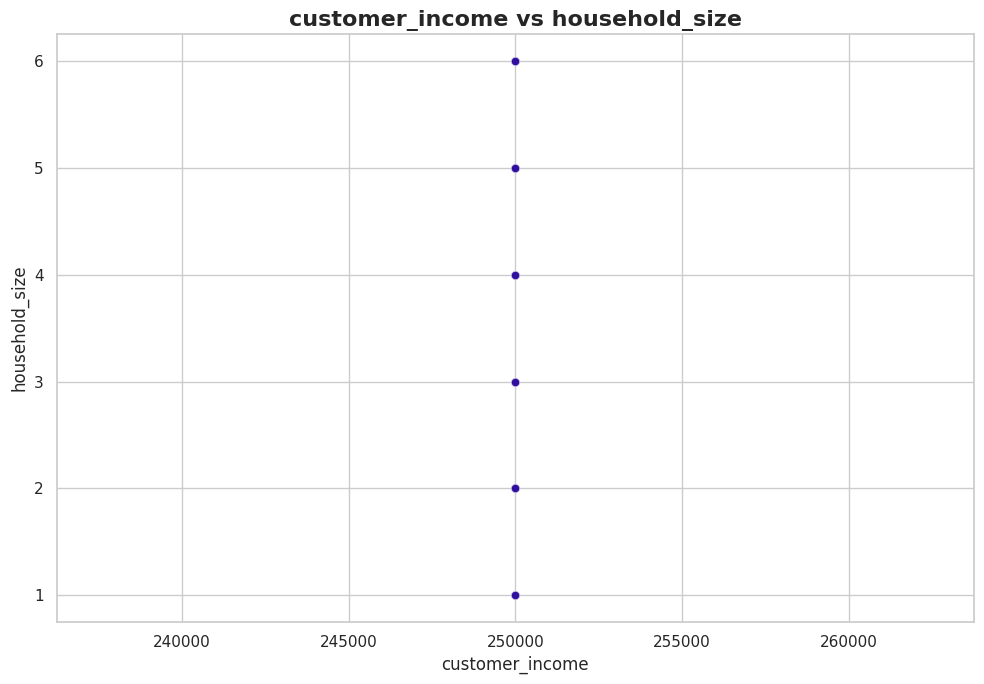

...

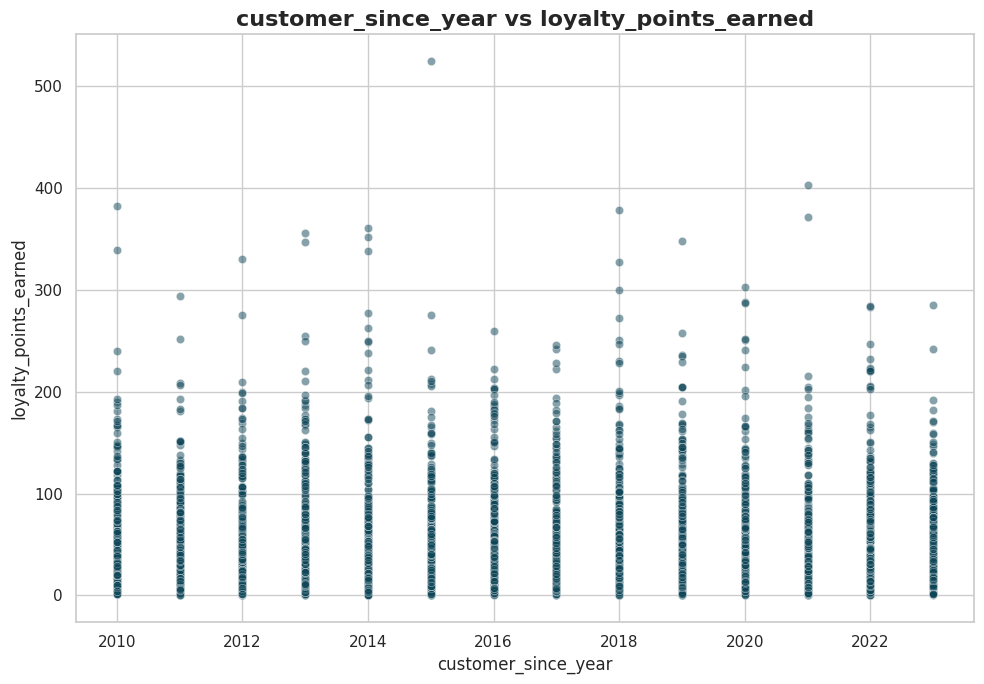

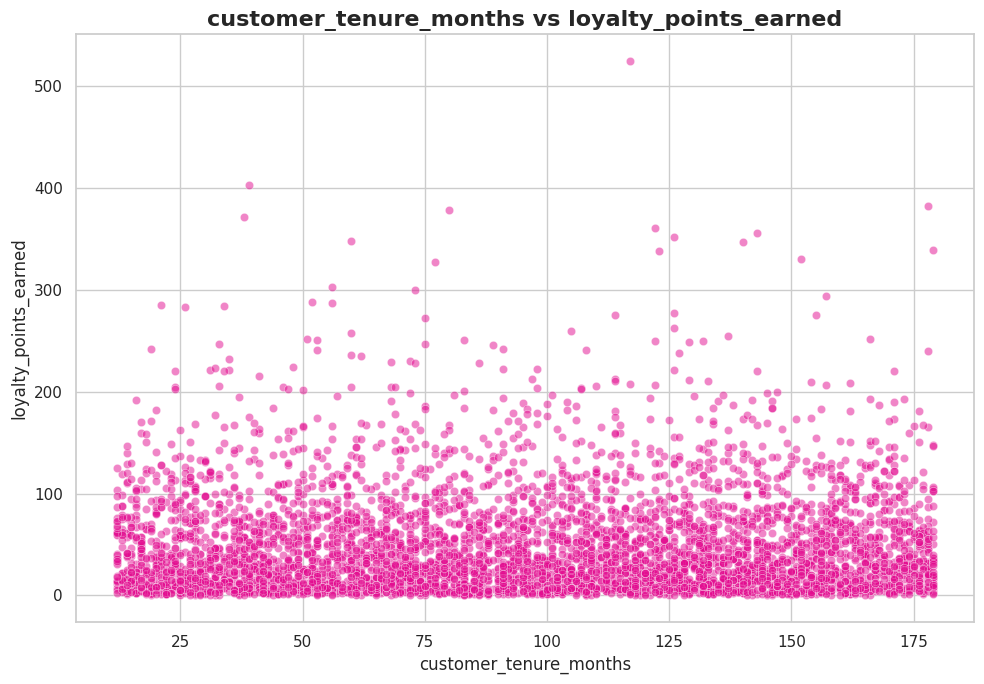

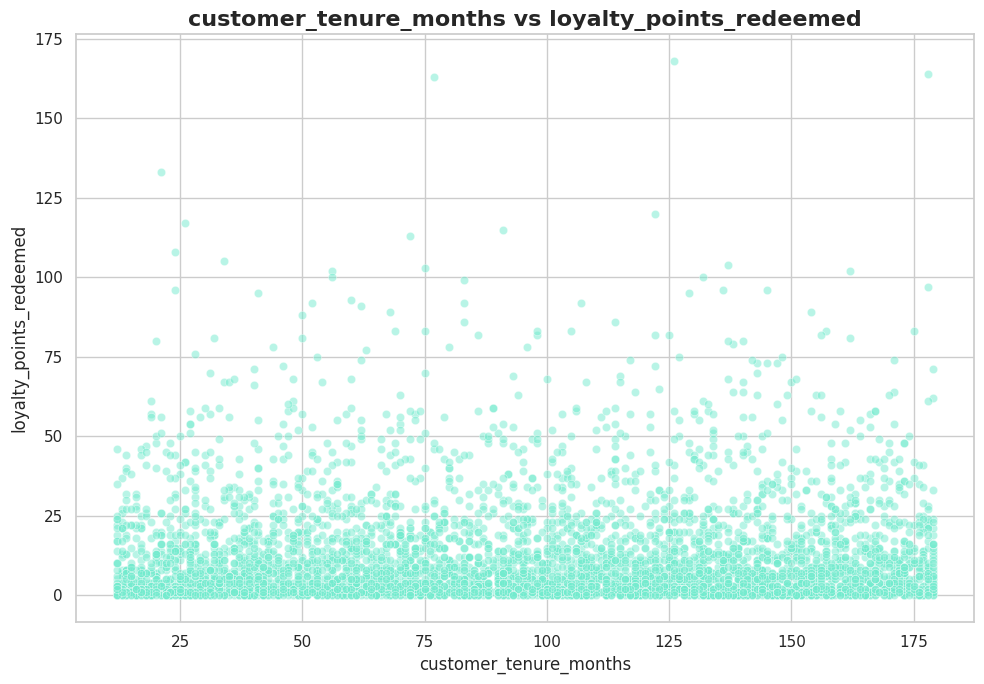

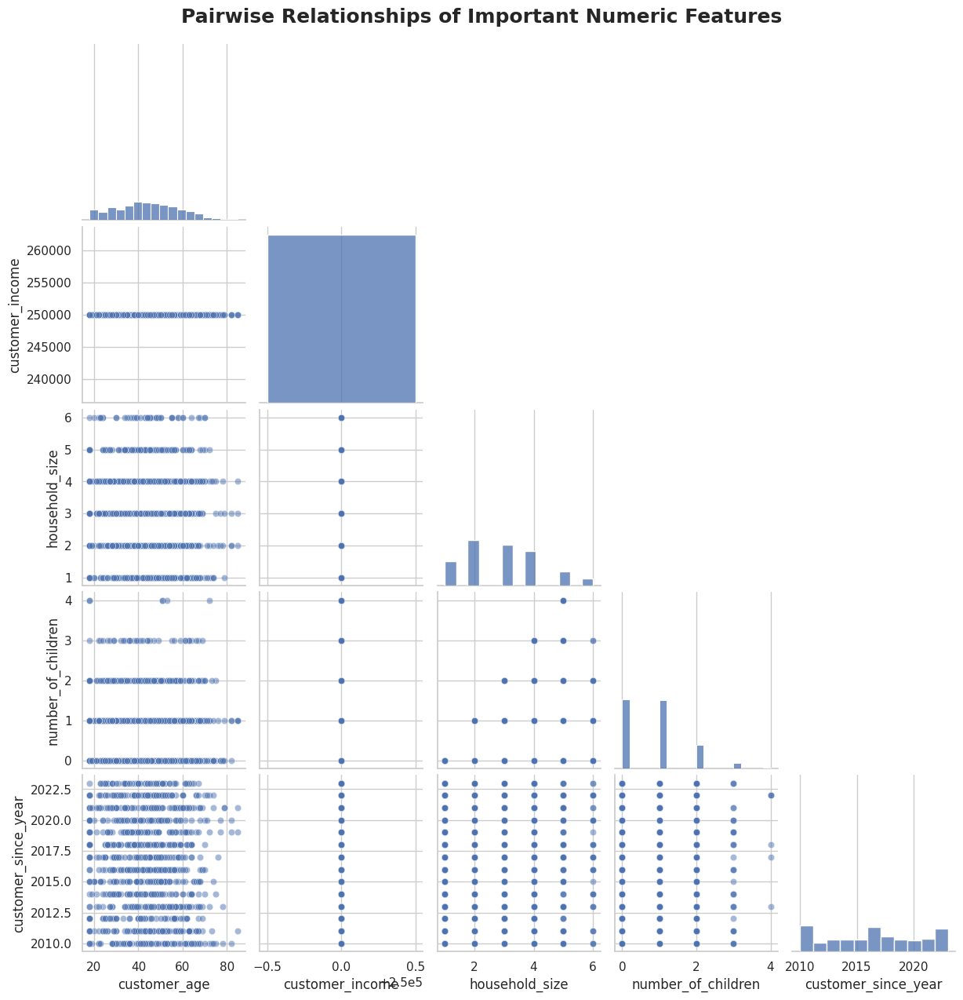

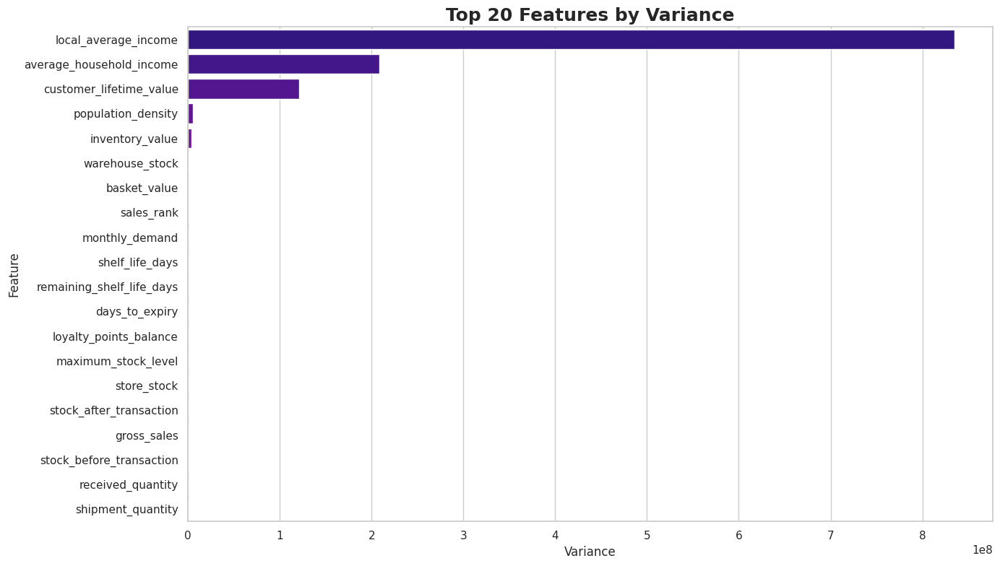


15. TOP HIGH-CARDINALITY COLUMNS


,Column,Unique_Count
0,transaction_id,120000
1,transaction_line_id,120000
97,transaction_datetime,119798
307,local_average_income,119292
61,average_household_income,118657
34,customer_lifetime_value,115481
59,longitude,107903
58,latitude,93424
3,customer_id,75799
187,inventory_value,69097


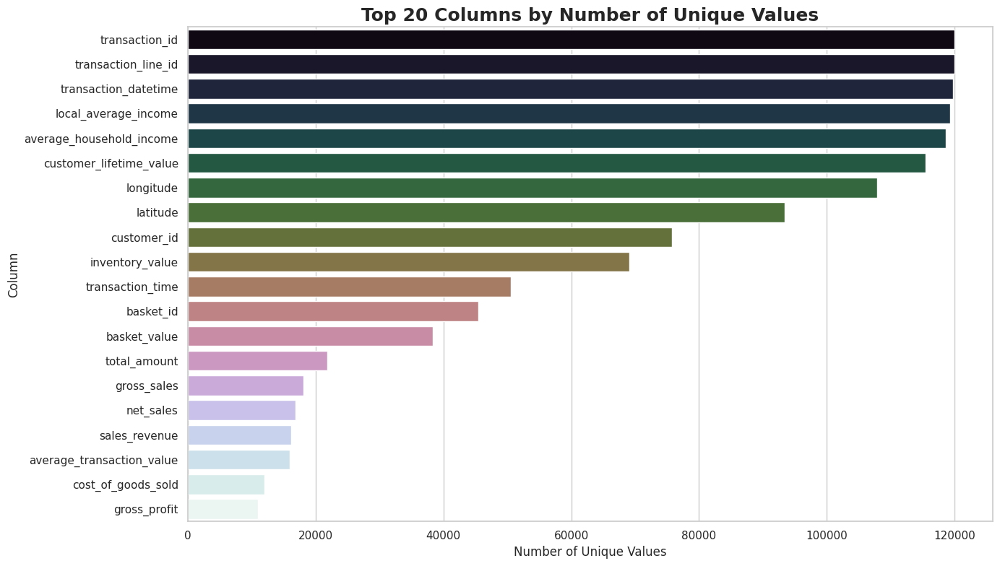


16. LOW-CARDINALITY FEATURES


,Column,Unique_Count
218,delivery_delay_days,10
62,nearby_competitor_count,10
301,competitor_count,10
245,holiday_name,9
129,impulse_purchase_count,9
...,...,...
25,loyalty_program_member,2
264,mobile_app_order,2
265,website_order,2
266,in_store_purchase,2



FINAL DATASET VISUALIZATION SUMMARY
Total rows              : 120,000
Total columns           : 323
Numeric columns         : 180
Categorical columns     : 143
Datetime columns        : 6
Duplicate rows          : 0
Missing cells           : 1,122,101
Columns with missing    : 28
High-cardinality cols   : 137

Visualization completed successfully.
END OF VISUALIZATION


In [12]:
# ============================================================
# COMPLETE DETAILED VISUALIZATION CODE
# Dataset: df
# Works with datasets having hundreds of columns
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Seaborn style
sns.set_theme(style="whitegrid")

print("=" * 100)
print("DATASET VISUALIZATION STARTED")
print("=" * 100)


# ============================================================
# 2. BASIC DATASET INFORMATION
# ============================================================

print("\n" + "=" * 100)
print("1. DATASET SHAPE")
print("=" * 100)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

print("\nColumn names:")
print(df.columns.tolist())


# ============================================================
# 3. DATA TYPES
# ============================================================

print("\n" + "=" * 100)
print("2. DATA TYPES")
print("=" * 100)

print(df.dtypes.value_counts())

print("\nDetailed data types:")
display(
    pd.DataFrame({
        "Column": df.columns,
        "Data_Type": df.dtypes.astype(str).values,
        "Unique_Values": [df[c].nunique(dropna=True) for c in df.columns],
        "Missing_Count": [df[c].isna().sum() for c in df.columns],
        "Missing_%": [
            round(df[c].isna().mean() * 100, 2)
            for c in df.columns
        ]
    })
)


# ============================================================
# 4. SEPARATE COLUMN TYPES
# ============================================================

numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

datetime_cols = df.select_dtypes(
    include=["datetime64[ns]", "datetime64[ns, UTC]"]
).columns.tolist()

print("\n" + "=" * 100)
print("3. COLUMN CATEGORIES")
print("=" * 100)

print(f"Numeric columns     : {len(numeric_cols)}")
print(f"Categorical columns : {len(categorical_cols)}")
print(f"Datetime columns    : {len(datetime_cols)}")


# ============================================================
# 5. AUTOMATIC DATE DETECTION
# ============================================================

# Try converting object columns that look like dates
possible_date_cols = []

for col in df.columns:

    if col in datetime_cols:
        continue

    if df[col].dtype == "object":

        sample = df[col].dropna().astype(str).head(100)

        if len(sample) == 0:
            continue

        converted = pd.to_datetime(
            sample,
            errors="coerce"
        )

        valid_ratio = converted.notna().mean()

        if valid_ratio >= 0.70:
            possible_date_cols.append(col)


print("\nPossible date columns:")
print(possible_date_cols)

# Convert detected date columns
for col in possible_date_cols:

    try:
        df[col] = pd.to_datetime(
            df[col],
            errors="coerce"
        )

        if col not in datetime_cols:
            datetime_cols.append(col)

    except:
        pass


# ============================================================
# 6. MISSING VALUE ANALYSIS
# ============================================================

missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().mean().values * 100
    )
})

missing_df = missing_df[
    missing_df["Missing_Count"] > 0
].sort_values(
    "Missing_Percentage",
    ascending=False
)

print("\n" + "=" * 100)
print("4. MISSING VALUE ANALYSIS")
print("=" * 100)

print(missing_df.head(30))


# ============================================================
# 7. MISSING VALUES BAR CHART
# ============================================================

if len(missing_df) > 0:

    top_missing = missing_df.head(30)

    plt.figure(figsize=(16, 9))

    sns.barplot(
        data=top_missing,
        x="Missing_Percentage",
        y="Column",
        palette="viridis"
    )

    plt.title(
        "Top 30 Columns by Missing Value Percentage",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Missing Values (%)")
    plt.ylabel("Column")

    plt.tight_layout()
    plt.show()


# ============================================================
# 8. MISSING VALUE HEATMAP
# ============================================================

if df.shape[1] <= 100:

    plt.figure(figsize=(18, 8))

    sns.heatmap(
        df.isnull(),
        cmap="magma",
        cbar=True,
        yticklabels=False
    )

    plt.title(
        "Missing Value Pattern",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Columns")
    plt.ylabel("Rows")

    plt.tight_layout()
    plt.show()


# ============================================================
# 9. DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()
duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print("\n" + "=" * 100)
print("5. DUPLICATE ANALYSIS")
print("=" * 100)

print(f"Duplicate rows       : {duplicate_count:,}")
print(f"Duplicate percentage  : {duplicate_percentage:.2f}%")


# ============================================================
# 10. NUMERIC SUMMARY
# ============================================================

if len(numeric_cols) > 0:

    print("\n" + "=" * 100)
    print("6. NUMERIC SUMMARY")
    print("=" * 100)

    numeric_summary = df[numeric_cols].describe().T

    numeric_summary["missing"] = (
        df[numeric_cols].isna().sum()
    )

    numeric_summary["unique"] = (
        df[numeric_cols].nunique()
    )

    display(numeric_summary)


# ============================================================
# 11. IDENTIFY IMPORTANT BUSINESS COLUMNS
# ============================================================

def find_columns(keywords):

    result = []

    for col in df.columns:

        col_lower = col.lower()

        if any(
            keyword in col_lower
            for keyword in keywords
        ):
            result.append(col)

    return result


revenue_cols = find_columns([
    "revenue",
    "sales",
    "amount",
    "price",
    "income",
    "turnover"
])

profit_cols = find_columns([
    "profit",
    "margin",
    "earnings"
])

quantity_cols = find_columns([
    "quantity",
    "units",
    "volume",
    "count"
])

customer_cols = find_columns([
    "customer"
])

product_cols = find_columns([
    "product"
])

store_cols = find_columns([
    "store"
])

category_cols = find_columns([
    "category"
])


print("\n" + "=" * 100)
print("7. IMPORTANT BUSINESS COLUMNS")
print("=" * 100)

print("Revenue/Sales:", revenue_cols)
print("Profit:", profit_cols)
print("Quantity:", quantity_cols)
print("Customer:", customer_cols)
print("Product:", product_cols)
print("Store:", store_cols)
print("Category:", category_cols)


# ============================================================
# 12. NUMERIC DISTRIBUTIONS
# ============================================================

# Select numerical columns with reasonable number of unique values
distribution_cols = [
    col for col in numeric_cols
    if df[col].nunique(dropna=True) > 1
]

# Limit to first 30 for readability
distribution_cols = distribution_cols[:30]

print("\n" + "=" * 100)
print("8. NUMERIC DISTRIBUTIONS")
print("=" * 100)

for col in distribution_cols:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df[col].dropna(),
        kde=True,
        bins=30,
        color=np.random.rand(3)
    )

    plt.title(
        f"Distribution of {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 13. BOXPLOTS FOR OUTLIER DETECTION
# ============================================================

boxplot_cols = distribution_cols[:20]

print("\n" + "=" * 100)
print("9. OUTLIER ANALYSIS")
print("=" * 100)

for col in boxplot_cols:

    plt.figure(figsize=(12, 5))

    sns.boxplot(
        x=df[col],
        color=np.random.rand(3)
    )

    plt.title(
        f"Boxplot - {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 14. NUMERIC CORRELATION HEATMAP
# ============================================================

if len(numeric_cols) >= 2:

    # Select columns with sufficient variation
    corr_cols = [
        col for col in numeric_cols
        if df[col].nunique(dropna=True) > 1
    ]

    # To avoid unreadable heatmaps with hundreds of columns,
    # select strongest varying numeric columns
    if len(corr_cols) > 40:

        variance_values = (
            df[corr_cols]
            .var(numeric_only=True)
            .sort_values(ascending=False)
        )

        corr_cols = variance_values.head(40).index.tolist()

    correlation_matrix = df[corr_cols].corr()

    plt.figure(
        figsize=(
            max(14, len(corr_cols) * 0.45),
            max(12, len(corr_cols) * 0.45)
        )
    )

    sns.heatmap(
        correlation_matrix,
        cmap="coolwarm",
        center=0,
        annot=False,
        linewidths=0.3
    )

    plt.title(
        "Numeric Feature Correlation Heatmap",
        fontsize=20,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 15. TOP CORRELATIONS
# ============================================================

if len(numeric_cols) >= 2:

    corr_matrix = df[numeric_cols].corr()

    corr_pairs = (
        corr_matrix
        .where(
            np.triu(
                np.ones(corr_matrix.shape),
                k=1
            ).astype(bool)
        )
        .stack()
        .reset_index()
    )

    corr_pairs.columns = [
        "Feature_1",
        "Feature_2",
        "Correlation"
    ]

    corr_pairs["Absolute_Correlation"] = (
        corr_pairs["Correlation"].abs()
    )

    corr_pairs = corr_pairs.sort_values(
        "Absolute_Correlation",
        ascending=False
    )

    print("\n" + "=" * 100)
    print("10. TOP 30 CORRELATED FEATURE PAIRS")
    print("=" * 100)

    display(
        corr_pairs.head(30)
    )


# ============================================================
# 16. TOP CORRELATION BAR CHART
# ============================================================

if len(numeric_cols) >= 2:

    top_corr = corr_pairs.head(20).copy()

    top_corr["Pair"] = (
        top_corr["Feature_1"]
        + " ↔ "
        + top_corr["Feature_2"]
    )

    plt.figure(figsize=(14, 9))

    sns.barplot(
        data=top_corr,
        x="Correlation",
        y="Pair",
        palette="coolwarm"
    )

    plt.title(
        "Top Feature Correlations",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Correlation")
    plt.ylabel("Feature Pair")

    plt.axvline(
        0,
        color="black",
        linestyle="--"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 17. CATEGORICAL COLUMN ANALYSIS
# ============================================================

# Avoid IDs and extremely high-cardinality columns
categorical_plot_cols = []

for col in categorical_cols:

    unique_count = df[col].nunique(dropna=True)

    if 2 <= unique_count <= 20:

        categorical_plot_cols.append(col)


categorical_plot_cols = categorical_plot_cols[:25]

print("\n" + "=" * 100)
print("11. CATEGORICAL COLUMNS")
print("=" * 100)

print(categorical_plot_cols)


# ============================================================
# 18. CATEGORICAL COUNT PLOTS
# ============================================================

for col in categorical_plot_cols:

    value_counts = (
        df[col]
        .value_counts(dropna=False)
        .head(15)
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=value_counts.values,
        y=value_counts.index.astype(str),
        palette="Set2"
    )

    plt.title(
        f"Category Distribution - {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. PIE CHARTS FOR SMALL CATEGORIES
# ============================================================

for col in categorical_plot_cols[:10]:

    value_counts = (
        df[col]
        .value_counts()
        .head(8)
    )

    plt.figure(figsize=(8, 8))

    plt.pie(
        value_counts.values,
        labels=value_counts.index.astype(str),
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette(
            "tab10",
            len(value_counts)
        )
    )

    plt.title(
        f"Percentage Distribution - {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. CUSTOMER AGE DISTRIBUTION
# ============================================================

age_cols = find_columns([
    "customer_age",
    "age"
])

age_cols = [
    col for col in age_cols
    if col in numeric_cols
]

for col in age_cols[:3]:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        color="teal"
    )

    plt.title(
        f"Customer Age Distribution - {col}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Age")
    plt.ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# 21. GENDER DISTRIBUTION
# ============================================================

gender_cols = [
    col for col in df.columns
    if "gender" in col.lower()
]

for col in gender_cols:

    counts = df[col].value_counts()

    plt.figure(figsize=(8, 6))

    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values,
        palette="pastel"
    )

    plt.title(
        f"Customer Gender Distribution - {col}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Gender")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()


# ============================================================
# 22. REVENUE / SALES VISUALIZATION
# ============================================================

print("\n" + "=" * 100)
print("12. SALES / REVENUE VISUALIZATION")
print("=" * 100)

for col in revenue_cols:

    if col not in numeric_cols:
        continue

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df[col].dropna(),
        kde=True,
        bins=30,
        color="royalblue"
    )

    plt.title(
        f"Distribution of {col}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 23. PROFIT VISUALIZATION
# ============================================================

print("\n" + "=" * 100)
print("13. PROFIT VISUALIZATION")
print("=" * 100)

for col in profit_cols:

    if col not in numeric_cols:
        continue

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df[col].dropna(),
        kde=True,
        bins=30,
        color="green"
    )

    plt.title(
        f"Profit Distribution - {col}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 24. REVENUE VS PROFIT SCATTER
# ============================================================

if len(revenue_cols) > 0 and len(profit_cols) > 0:

    revenue_col = next(
        (
            col for col in revenue_cols
            if col in numeric_cols
        ),
        None
    )

    profit_col = next(
        (
            col for col in profit_cols
            if col in numeric_cols
        ),
        None
    )

    if revenue_col and profit_col:

        temp = df[
            [revenue_col, profit_col]
        ].dropna()

        # Prevent extremely large plotting workload
        if len(temp) > 10000:
            temp = temp.sample(
                10000,
                random_state=42
            )

        plt.figure(figsize=(12, 7))

        sns.scatterplot(
            data=temp,
            x=revenue_col,
            y=profit_col,
            alpha=0.6,
            color="purple"
        )

        plt.title(
            f"{revenue_col} vs {profit_col}",
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel(revenue_col)
        plt.ylabel(profit_col)

        plt.tight_layout()
        plt.show()


# ============================================================
# 25. UNITS SOLD VISUALIZATION
# ============================================================

for col in quantity_cols:

    if col not in numeric_cols:
        continue

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True,
        color="orange"
    )

    plt.title(
        f"Distribution of {col}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 26. PRODUCT POPULARITY / RANK ANALYSIS
# ============================================================

popularity_cols = find_columns([
    "popularity",
    "rank",
    "growth_rate",
    "return_rate",
    "stockout_rate"
])

popularity_numeric = [
    col for col in popularity_cols
    if col in numeric_cols
]

print("\nPopularity / ranking columns:")
print(popularity_numeric)

for col in popularity_numeric[:15]:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df[col].dropna(),
        kde=True,
        bins=30,
        color=np.random.rand(3)
    )

    plt.title(
        f"Distribution of {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 27. TOP PRODUCTS
# ============================================================

product_id_cols = [
    col for col in df.columns
    if "product" in col.lower()
]

sales_value_col = None

for col in [
    "sales_revenue",
    "sales",
    "revenue",
    "sales_amount"
]:

    if col in df.columns and col in numeric_cols:
        sales_value_col = col
        break


if product_id_cols and sales_value_col:

    product_col = product_id_cols[0]

    product_sales = (
        df.groupby(product_col)[sales_value_col]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(14, 8))

    sns.barplot(
        x=product_sales.values,
        y=product_sales.index.astype(str),
        palette="viridis"
    )

    plt.title(
        f"Top 15 Products by {sales_value_col}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(sales_value_col)
    plt.ylabel(product_col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 28. TOP STORES
# ============================================================

if store_cols and sales_value_col:

    store_col = store_cols[0]

    store_sales = (
        df.groupby(store_col)[sales_value_col]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(14, 8))

    sns.barplot(
        x=store_sales.values,
        y=store_sales.index.astype(str),
        palette="magma"
    )

    plt.title(
        f"Top Stores by {sales_value_col}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(sales_value_col)
    plt.ylabel(store_col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 29. CATEGORY SALES
# ============================================================

if category_cols and sales_value_col:

    category_col = category_cols[0]

    category_sales = (
        df.groupby(category_col)[sales_value_col]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(14, 8))

    sns.barplot(
        x=category_sales.values,
        y=category_sales.index.astype(str),
        palette="Set1"
    )

    plt.title(
        f"Sales by {category_col}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(sales_value_col)
    plt.ylabel(category_col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 30. DATE / TIME SERIES ANALYSIS
# ============================================================

print("\n" + "=" * 100)
print("14. TIME SERIES ANALYSIS")
print("=" * 100)

if datetime_cols:

    date_col = datetime_cols[0]

    print("Using date column:", date_col)

    # Find revenue column
    if sales_value_col:

        temp = df[
            [date_col, sales_value_col]
        ].dropna()

        if len(temp) > 0:

            temp["Month"] = (
                temp[date_col]
                .dt.to_period("M")
                .astype(str)
            )

            monthly_sales = (
                temp.groupby("Month")[sales_value_col]
                .sum()
                .reset_index()
            )

            plt.figure(figsize=(16, 7))

            sns.lineplot(
                data=monthly_sales,
                x="Month",
                y=sales_value_col,
                marker="o",
                linewidth=2.5,
                color="darkblue"
            )

            plt.title(
                f"Monthly {sales_value_col} Trend",
                fontsize=18,
                fontweight="bold"
            )

            plt.xlabel("Month")
            plt.ylabel(sales_value_col)

            plt.xticks(rotation=45)

            plt.tight_layout()
            plt.show()


# ============================================================
# 31. DAILY SALES TREND
# ============================================================

if datetime_cols and sales_value_col:

    date_col = datetime_cols[0]

    temp = df[
        [date_col, sales_value_col]
    ].dropna()

    if len(temp) > 0:

        temp["Date"] = temp[date_col].dt.date

        daily_sales = (
            temp.groupby("Date")[sales_value_col]
            .sum()
            .reset_index()
        )

        if len(daily_sales) > 1:

            plt.figure(figsize=(16, 7))

            sns.lineplot(
                data=daily_sales,
                x="Date",
                y=sales_value_col,
                color="crimson",
                linewidth=2
            )

            plt.title(
                f"Daily {sales_value_col} Trend",
                fontsize=18,
                fontweight="bold"
            )

            plt.xlabel("Date")
            plt.ylabel(sales_value_col)

            plt.xticks(rotation=45)

            plt.tight_layout()
            plt.show()


# ============================================================
# 32. SCATTER PLOT FOR TOP NUMERIC FEATURES
# ============================================================

if len(numeric_cols) >= 2:

    scatter_cols = numeric_cols[:10]

    for i in range(
        min(len(scatter_cols), 6)
    ):

        x_col = scatter_cols[i]

        for j in range(
            i + 1,
            min(len(scatter_cols), i + 3)
        ):

            y_col = scatter_cols[j]

            temp = df[
                [x_col, y_col]
            ].dropna()

            if len(temp) == 0:
                continue

            if len(temp) > 5000:
                temp = temp.sample(
                    5000,
                    random_state=42
                )

            plt.figure(figsize=(10, 7))

            sns.scatterplot(
                data=temp,
                x=x_col,
                y=y_col,
                alpha=0.5,
                color=np.random.rand(3)
            )

            plt.title(
                f"{x_col} vs {y_col}",
                fontsize=16,
                fontweight="bold"
            )

            plt.xlabel(x_col)
            plt.ylabel(y_col)

            plt.tight_layout()
            plt.show()


# ============================================================
# 33. PAIRPLOT FOR IMPORTANT NUMERIC FEATURES
# ============================================================

# Pairplot can become very heavy.
# Therefore only use maximum 5 important numeric columns.

if len(numeric_cols) >= 2:

    pair_cols = numeric_cols[:5]

    pair_df = df[pair_cols].dropna()

    if len(pair_df) > 1000:

        pair_df = pair_df.sample(
            1000,
            random_state=42
        )

    if len(pair_df) > 1:

        sns.pairplot(
            pair_df,
            diag_kind="hist",
            corner=True,
            plot_kws={
                "alpha": 0.5
            }
        )

        plt.suptitle(
            "Pairwise Relationships of Important Numeric Features",
            y=1.02,
            fontsize=18,
            fontweight="bold"
        )

        plt.show()


# ============================================================
# 34. TOP VARIANCE FEATURES
# ============================================================

if len(numeric_cols) > 0:

    variance_df = (
        df[numeric_cols]
        .var()
        .sort_values(ascending=False)
        .head(20)
    )

    plt.figure(figsize=(14, 8))

    sns.barplot(
        x=variance_df.values,
        y=variance_df.index,
        palette="plasma"
    )

    plt.title(
        "Top 20 Features by Variance",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Variance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


# ============================================================
# 35. UNIQUE VALUE ANALYSIS
# ============================================================

unique_df = pd.DataFrame({
    "Column": df.columns,
    "Unique_Count": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ]
})

unique_df = unique_df.sort_values(
    "Unique_Count",
    ascending=False
)

print("\n" + "=" * 100)
print("15. TOP HIGH-CARDINALITY COLUMNS")
print("=" * 100)

display(
    unique_df.head(30)
)


# ============================================================
# 36. UNIQUE VALUE BAR CHART
# ============================================================

top_unique = unique_df.head(20)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top_unique,
    x="Unique_Count",
    y="Column",
    palette="cubehelix"
)

plt.title(
    "Top 20 Columns by Number of Unique Values",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Unique Values")
plt.ylabel("Column")

plt.tight_layout()
plt.show()


# ============================================================
# 37. LOW-CARDINALITY FEATURE ANALYSIS
# ============================================================

low_cardinality = unique_df[
    (unique_df["Unique_Count"] >= 2) &
    (unique_df["Unique_Count"] <= 10)
]

print("\n" + "=" * 100)
print("16. LOW-CARDINALITY FEATURES")
print("=" * 100)

display(
    low_cardinality
)


# ============================================================
# 38. SUMMARY DASHBOARD
# ============================================================

print("\n" + "=" * 100)
print("FINAL DATASET VISUALIZATION SUMMARY")
print("=" * 100)

print(f"Total rows              : {df.shape[0]:,}")
print(f"Total columns           : {df.shape[1]:,}")
print(f"Numeric columns         : {len(numeric_cols)}")
print(f"Categorical columns     : {len(categorical_cols)}")
print(f"Datetime columns        : {len(datetime_cols)}")
print(f"Duplicate rows          : {duplicate_count:,}")
print(
    f"Missing cells           : {df.isna().sum().sum():,}"
)

print(
    f"Columns with missing    : {len(missing_df)}"
)

print(
    f"High-cardinality cols   : "
    f"{sum(unique_df['Unique_Count'] > 50)}"
)

print("\nVisualization completed successfully.")

print("=" * 100)
print("END OF VISUALIZATION")
print("=" * 100)

## Feature engineering

DATASET INFORMATION
Dataset shape: (120000, 323)

First 5 rows:


,transaction_id,transaction_line_id,basket_id,customer_id,store_id,product_id,employee_id,supplier_id,customer_age,customer_gender,customer_marital_status,customer_education,customer_occupation,customer_income,household_size,number_of_children,customer_segment,customer_region,customer_city,customer_area_type,urban_rural,customer_membership_status,membership_tier,customer_since_year,customer_tenure_months,loyalty_program_member,loyalty_points_earned,loyalty_points_redeemed,loyalty_points_balance,loyalty_tier,membership_duration_months,customer_visit_frequency,average_monthly_visits,average_transaction_value,customer_lifetime_value,customer_retention_score,customer_churn_risk,customer_engagement_score,store_size_sqft,store_type,store_format,store_age_years,store_region,store_city,store_area_type,number_of_employees,number_of_checkout_counters,number_of_self_checkout_counters,parking_spaces,daily_customer_capacity,store_rating,store_operational_status,country,region,state_province,city,district,neighborhood_type,latitude,longitude,population_density,average_household_income,nearby_competitor_count,shopping_center_presence,public_transport_access,parking_availability,product_name,product_category,product_subcategory,product_department,brand,brand_type,product_type,product_size,unit_of_measure,package_quantity,package_weight,product_perishable,product_age_days,product_status,country_of_origin,product_segment,unit_cost,regular_price,selling_price,discount_amount,discount_percent,tax_rate,tax_amount,final_unit_price,wholesale_price,supplier_price,price_index,competitor_price,price_difference_from_competitor,transaction_date,transaction_time,transaction_datetime,day_of_week,day_name,week_number,month,month_name,quarter,year,is_weekend,is_holiday,holiday_type,season,shopping_hour,shopping_period,quantity,unit_price,gross_sales,net_sales,total_amount,cost_of_goods_sold,gross_profit,profit_margin_percent,basket_size,number_of_items,number_of_unique_products,items_per_transaction,unique_categories_in_basket,average_item_price,average_discount_percent,basket_value,premium_product_count,budget_product_count,impulse_purchase_count,essential_item_count,purchase_frequency,repeat_purchase,days_since_last_purchase,product_popularity_score,product_demand_score,customer_product_affinity,product_purchase_probability,cross_sell_score,upsell_score,promotion_active,promotion_type,promotion_id,promotion_duration_days,promotion_channel,promotion_discount_percent,coupon_used,coupon_value,loyalty_discount,bundle_offer,buy_one_get_one,clearance_sale,seasonal_promotion,marketing_channel,campaign_id,campaign_exposure,email_campaign,sms_campaign,mobile_app_notification,social_media_exposure,advertisement_exposure,coupon_received,coupon_redeemed,campaign_response,marketing_engagement_score,payment_method,payment_channel,payment_status,card_type,digital_wallet,cash_payment,credit_card_payment,debit_card_payment,mobile_payment,gift_card_payment,payment_processing_time_seconds,stock_before_transaction,quantity_sold,stock_after_transaction,reorder_level,maximum_stock_level,safety_stock,inventory_turnover_rate,days_of_inventory,stockout_status,low_stock_status,overstock_status,inventory_value,warehouse_stock,store_stock,reorder_quantity,reorder_status,daily_demand,weekly_demand,monthly_demand,demand_forecast,forecast_error,demand_growth_rate,seasonal_demand_index,demand_volatility,product_demand_category,supplier_region,supplier_type,supplier_rating,supplier_reliability_score,supplier_lead_time_days,supplier_minimum_order_quantity,supplier_on_time_delivery_rate,supplier_defect_rate,supplier_contract_status,order_date,delivery_date,lead_time_days,warehouse_id,distribution_center,shipping_method,transportation_mode,delivery_status,delivery_delay_days,shipment_quantity,damaged_quantity,received_quantity,product_quality_score,quality_check_status,defect_rate,damaged_product,expired_product,near_expiry_status,return_rate,customer_complaint_rate,perishable_flag,shelf_lif


Number of rows: 120000
Number of columns: 323

DUPLICATE COLUMN CHECK
Duplicate columns: 0
Shape after duplicate-column removal: (120000, 323)

TARGET CHECK
Target source: expiry_risk_score

Target data type:
float64

Target statistics:
count    114014.00000
mean          0.30647
std           0.18887
min           0.00000
25%           0.16500
50%           0.30100
75%           0.43600
max           1.00000
Name: expiry_risk_score, dtype: float64

Number of unique target values:
968

Sample target values:
[0.418, 0.269, 0.075, 0.431, 0.141, 0.238, 0.529, 0.511, 0.126, 0.233, 0.577, 0.307, 0.252, 0.525, 0.054, 0.67, nan, 0.355, 0.053, 0.191]

TARGET PREPARATION
Rows removed because target was missing: 5986

Unique target values: 968

Continuous/multi-value risk score detected.
Risk threshold (70th percentile): 0.407
Class 0 = lower risk
Class 1 = high risk

TARGET DISTRIBUTION
Expiry_Risk
0    79676
1    34338
Name: count, dtype: int64

Target percentages:
Expiry_Risk
0    69.88
1   

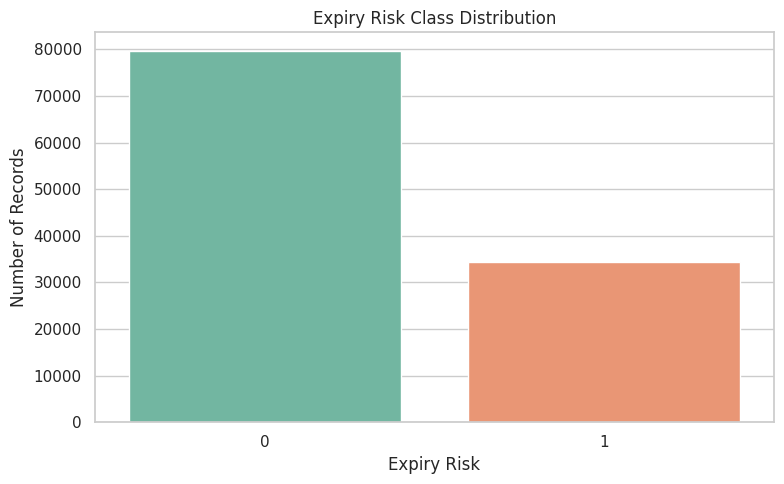


FEATURE / TARGET PREPARATION
X shape: (114014, 322)
y shape: (114014,)

CONSTANT COLUMN REMOVAL
Constant columns: 6
Removing first columns:
['store_size_sqft', 'country', 'stockout_status', 'low_stock_status', 'reorder_quantity', 'reorder_status']
Shape after constant-column removal: (114014, 316)

ID COLUMN DETECTION
Detected ID columns: 11
['transaction_id', 'transaction_line_id', 'basket_id', 'customer_id', 'store_id', 'product_id', 'employee_id', 'supplier_id', 'promotion_id', 'campaign_id', 'warehouse_id']
Shape after ID removal: (114014, 305)

DATE / TIME PROCESSING
Detected datetime columns:
['customer_lifetime_value', 'transaction_date', 'transaction_time', 'transaction_datetime', 'payment_processing_time_seconds', 'supplier_lead_time_days', 'supplier_on_time_delivery_rate', 'order_date', 'delivery_date', 'lead_time_days', 'expiry_date', 'delivery_time_minutes', 'complaint_resolution_time_hours', 'checkout_wait_time_minutes']

HIGH CARDINALITY CHECK
High-cardinality categorica

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Naive Bayes,0.5798,0.3019,0.3011,0.3015,0.4964
1,KNN,0.6470,0.2969,0.1258,0.1767,0.4955
2,Decision Tree,0.6864,0.3080,0.0331,0.0597,0.5006
3,Random Forest,0.6988,0.0000,0.0000,0.0000,0.4973
4,Logistic Regression,0.6987,0.0000,0.0000,0.0000,0.4920
5,Gradient Boosting,0.6988,0.0000,0.0000,0.0000,0.5032
6,Extra Trees,0.6988,0.0000,0.0000,0.0000,0.4966
7,Hist Gradient Boosting,0.6988,0.0000,0.0000,0.0000,0.4941
8,XGBoost,0.6988,0.0000,0.0000,0.0000,0.4976
9,LightGBM,0.6988,0.0000,0.0000,0.0000,0.4948


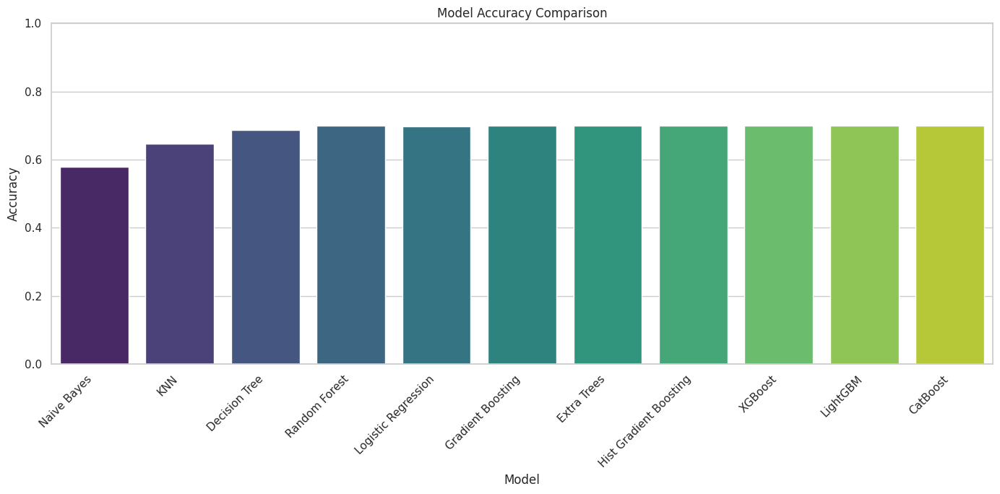

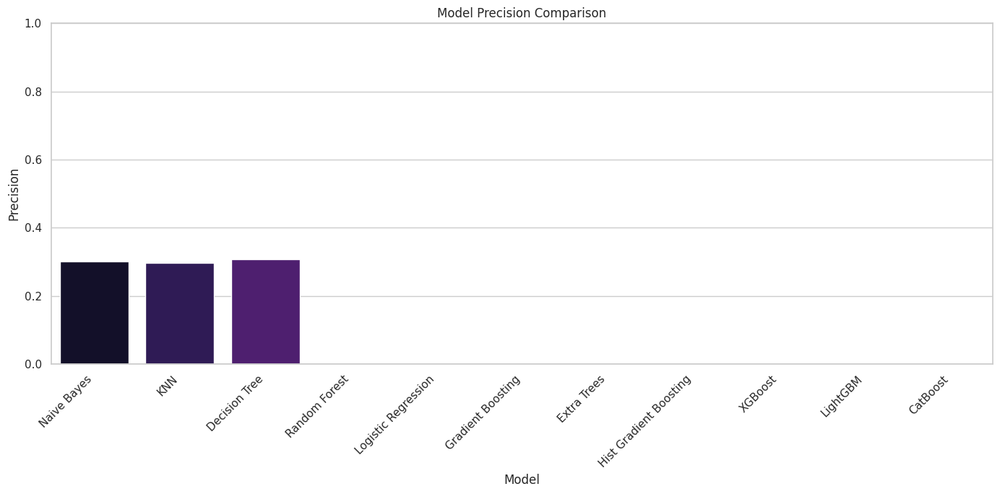

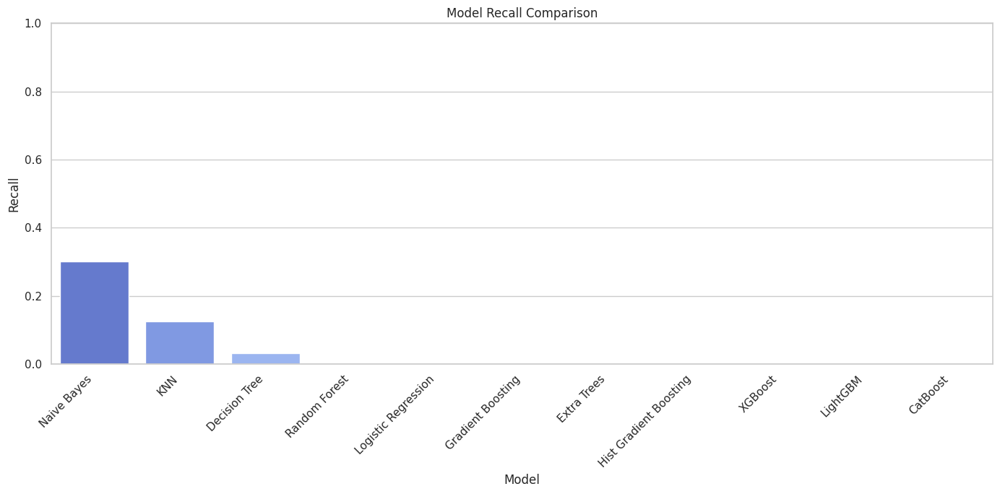

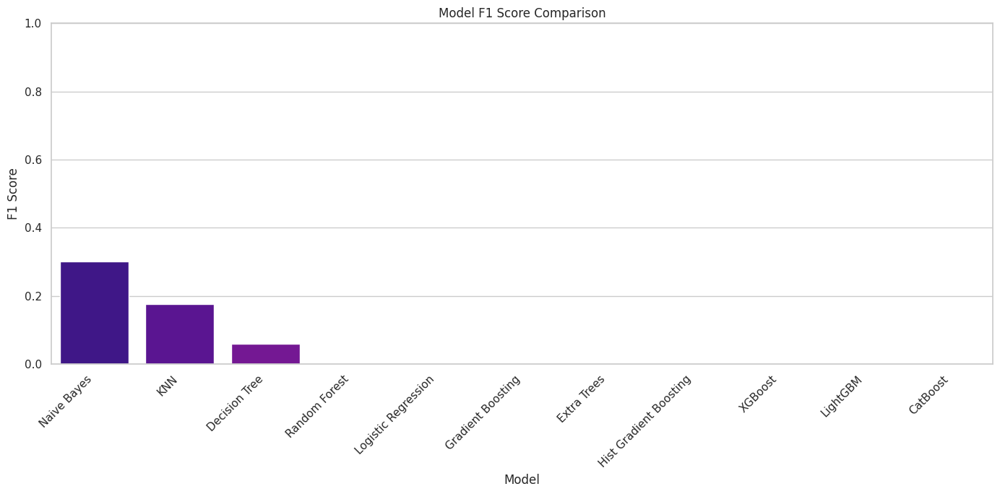

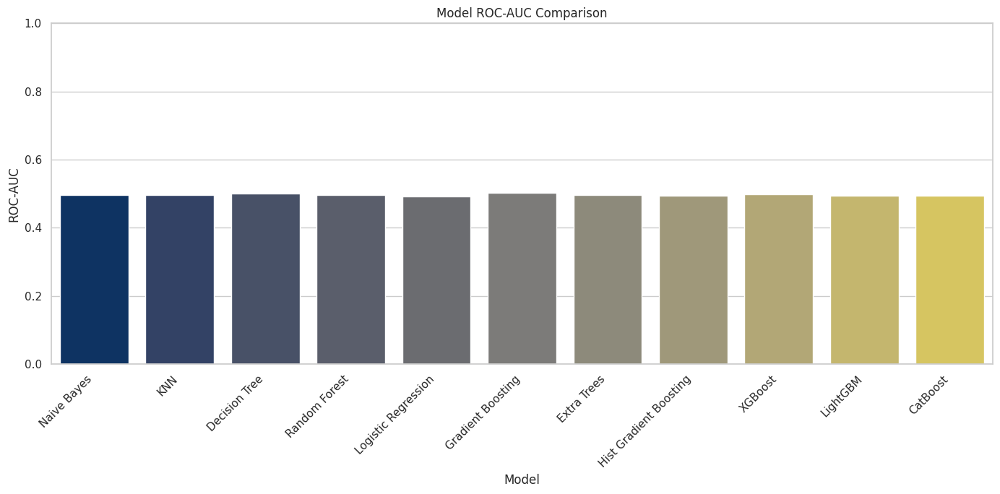

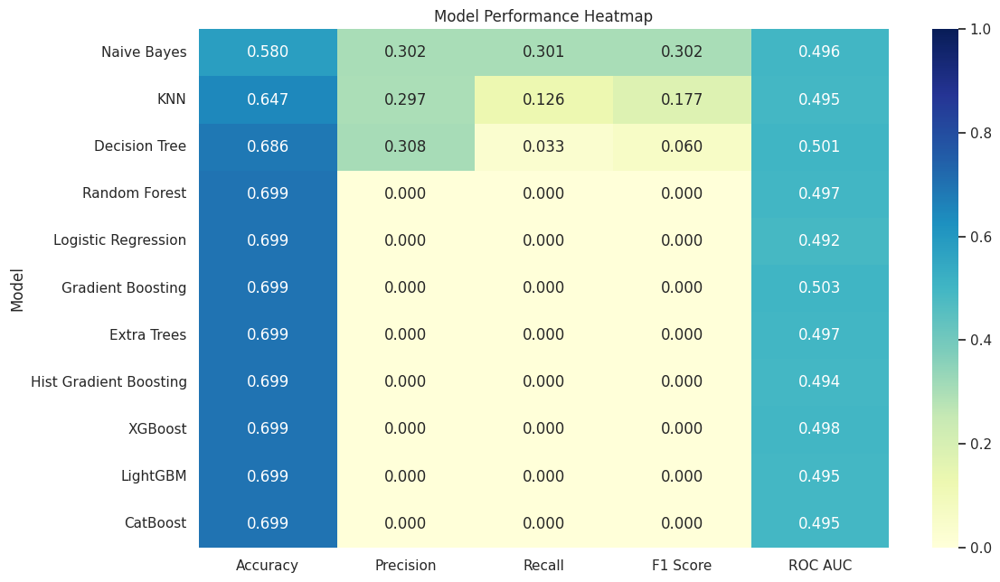


BEST MODEL
Best model: Naive Bayes
Best F1: 0.301523656776263
Best ROC-AUC: 0.49640822071464985

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Low Risk       0.70      0.70      0.70     15935
   High Risk       0.30      0.30      0.30      6868

    accuracy                           0.58     22803
   macro avg       0.50      0.50      0.50     22803
weighted avg       0.58      0.58      0.58     22803


Confusion Matrix:
[[11154  4781]
 [ 4800  2068]]


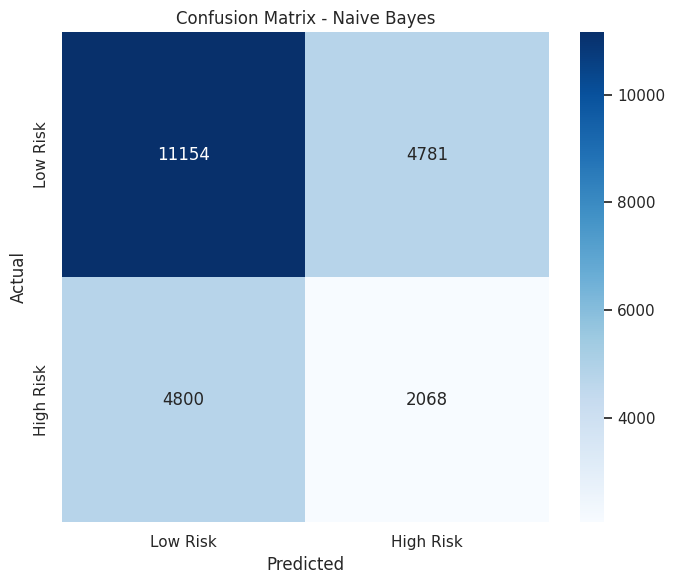

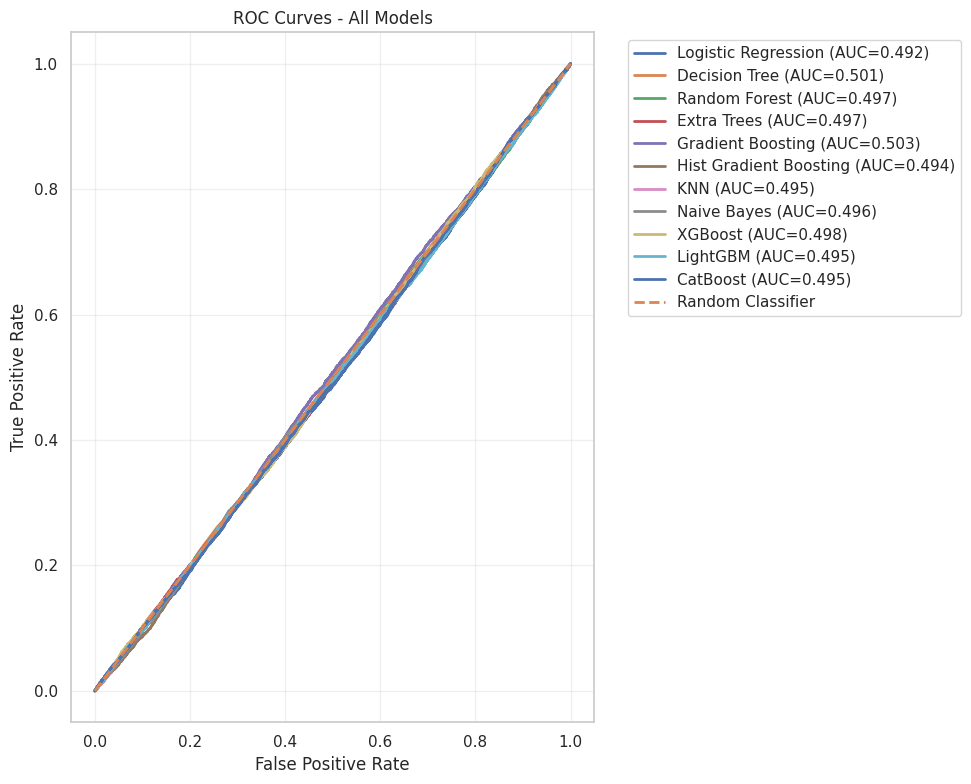

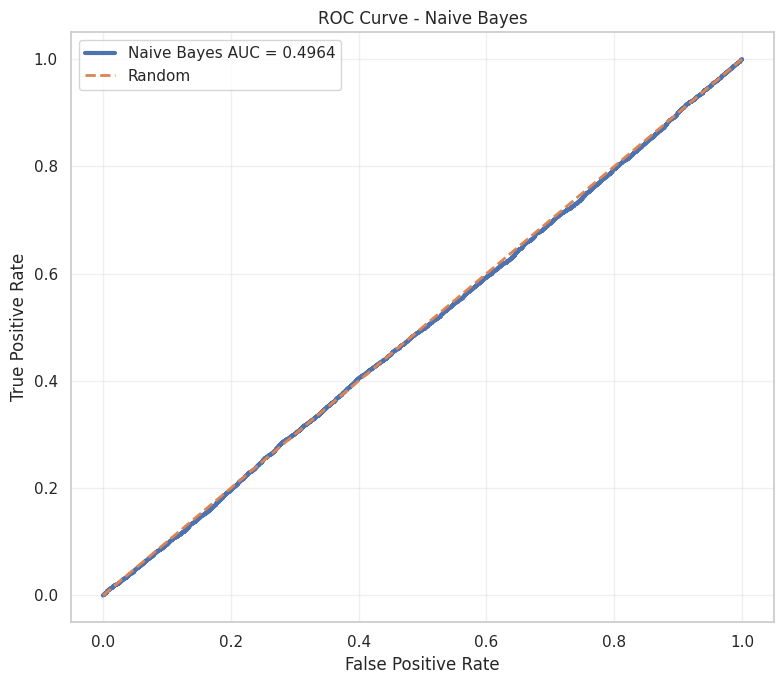


FINAL FEATURE INFORMATION
Number of processed features: 704

FEATURE IMPORTANCE
Feature importance is not available for this model.

ACTUAL VS PREDICTED


,Actual,Predicted,Correct
0,0,0,True
1,0,0,True
2,0,0,True
3,0,1,False
4,1,0,False
5,0,1,False
6,1,1,True
7,0,1,False
8,0,1,False
9,0,0,True


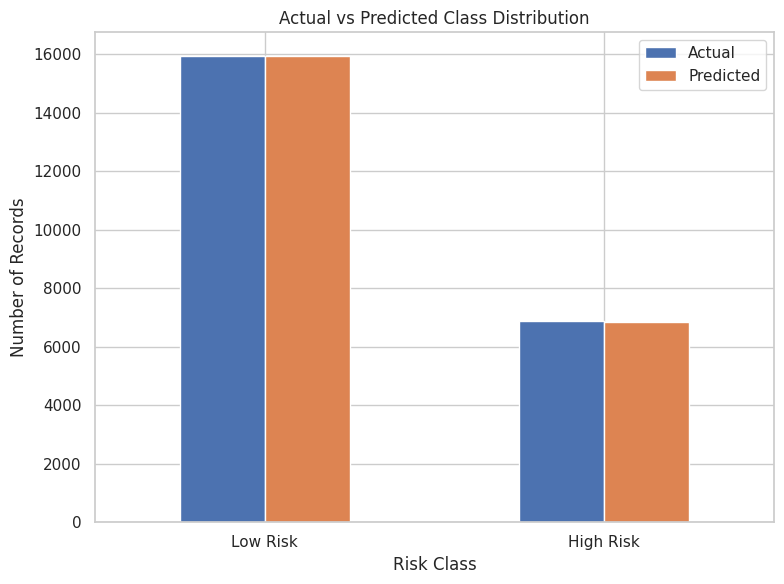


SAVING RESULTS
Saved: model_comparison.csv
Saved: actual_vs_predicted.csv

FINAL ML SUMMARY
Original dataset shape : (114014, 324)
Final feature columns  : 358
Training rows          : 91211
Testing rows           : 22803
Processed features     : 704
Target source          : expiry_risk_score
Classification target  : Expiry_Risk
Risk threshold         : 0.4070
Best model             : Naive Bayes
Accuracy               : 0.5798
Precision              : 0.3019
Recall                 : 0.3011
F1 Score               : 0.3015
ROC-AUC                : 0.4964

ML PIPELINE COMPLETED SUCCESSFULLY.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.base import clone

# Optional ML libraries
HAS_XGBOOST = False
HAS_LIGHTGBM = False
HAS_CATBOOST = False

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except:
    pass

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except:
    pass

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except:
    pass


# ================================================================
# 2. CONFIGURATION
# ================================================================

TARGET_SOURCE = "expiry_risk_score"

TARGET_COLUMN = "Expiry_Risk"

TEST_SIZE = 0.20

RANDOM_STATE = 42

# Top 30% score = High Risk
RISK_QUANTILE = 0.70

# Maximum categories retained for one-hot encoding
MAX_CATEGORIES = 100

# Maximum number of features used for plots
MAX_PLOT_FEATURES = 30


# ================================================================
# 3. CHECK DATAFRAME
# ================================================================

print("=" * 90)
print("DATASET INFORMATION")
print("=" * 90)

if "df" not in globals():
    raise ValueError(
        "DataFrame 'df' was not found. Please load your dataset into df first."
    )

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nNumber of rows:", len(df))
print("Number of columns:", len(df.columns))


# ================================================================
# 4. REMOVE DUPLICATE COLUMNS
# ================================================================

print("\n" + "=" * 90)
print("DUPLICATE COLUMN CHECK")
print("=" * 90)

duplicate_columns = df.columns[df.columns.duplicated()].tolist()

print("Duplicate columns:", len(duplicate_columns))

if len(duplicate_columns) > 0:
    print("Removing duplicate columns:")
    print(duplicate_columns)

    df = df.loc[:, ~df.columns.duplicated()].copy()

print("Shape after duplicate-column removal:", df.shape)


# ================================================================
# 5. CHECK TARGET
# ================================================================

print("\n" + "=" * 90)
print("TARGET CHECK")
print("=" * 90)

if TARGET_SOURCE not in df.columns:

    print("Target source not found:", TARGET_SOURCE)

    print("\nPossible target-related columns:")

    possible_targets = [
        col for col in df.columns
        if any(
            word in str(col).lower()
            for word in [
                "expiry",
                "risk",
                "target",
                "status",
                "class",
                "label"
            ]
        )
    ]

    print(possible_targets)

    raise ValueError(
        f"'{TARGET_SOURCE}' does not exist in df. "
        "Change TARGET_SOURCE to the correct target column."
    )

print("Target source:", TARGET_SOURCE)

print("\nTarget data type:")
print(df[TARGET_SOURCE].dtype)

print("\nTarget statistics:")
print(df[TARGET_SOURCE].describe())

print("\nNumber of unique target values:")
print(df[TARGET_SOURCE].nunique())

print("\nSample target values:")
print(df[TARGET_SOURCE].head(20).tolist())


# ================================================================
# 6. CLEAN TARGET
# ================================================================

print("\n" + "=" * 90)
print("TARGET PREPARATION")
print("=" * 90)

# Convert target to numeric where possible
df[TARGET_SOURCE] = pd.to_numeric(
    df[TARGET_SOURCE],
    errors="coerce"
)

# Remove rows where target is missing
before_rows = len(df)

df = df.dropna(
    subset=[TARGET_SOURCE]
).copy()

after_rows = len(df)

print("Rows removed because target was missing:", before_rows - after_rows)


# ================================================================
# 7. CREATE CLASSIFICATION TARGET
# ================================================================

unique_target_values = df[TARGET_SOURCE].nunique()

print("\nUnique target values:", unique_target_values)

if unique_target_values == 2:

    # Already binary
    unique_values = sorted(
        df[TARGET_SOURCE].unique()
    )

    target_mapping = {
        unique_values[0]: 0,
        unique_values[1]: 1
    }

    df[TARGET_COLUMN] = df[TARGET_SOURCE].map(
        target_mapping
    ).astype(int)

    print("\nDetected binary target.")

    print("Target mapping:")
    print(target_mapping)

else:

    # Continuous / multi-value risk score
    threshold = df[TARGET_SOURCE].quantile(
        RISK_QUANTILE
    )

    df[TARGET_COLUMN] = (
        df[TARGET_SOURCE] >= threshold
    ).astype(int)

    print("\nContinuous/multi-value risk score detected.")

    print(
        f"Risk threshold ({RISK_QUANTILE * 100:.0f}th percentile):",
        threshold
    )

    print(
        "Class 0 = lower risk"
    )

    print(
        "Class 1 = high risk"
    )


# ================================================================
# 8. TARGET DISTRIBUTION
# ================================================================

print("\n" + "=" * 90)
print("TARGET DISTRIBUTION")
print("=" * 90)

target_counts = df[TARGET_COLUMN].value_counts().sort_index()

print(target_counts)

print("\nTarget percentages:")
print(
    (target_counts / len(df) * 100).round(2)
)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x=TARGET_COLUMN,
    hue=TARGET_COLUMN,
    palette="Set2",
    legend=False
)

plt.title("Expiry Risk Class Distribution")
plt.xlabel("Expiry Risk")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


# ================================================================
# 9. PREPARE X AND y
# ================================================================

print("\n" + "=" * 90)
print("FEATURE / TARGET PREPARATION")
print("=" * 90)

# IMPORTANT:
# Remove both target and original risk score.
# This prevents direct target leakage.

X = df.drop(
    columns=[
        TARGET_COLUMN,
        TARGET_SOURCE
    ],
    errors="ignore"
).copy()

y = df[TARGET_COLUMN].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


# ================================================================
# 10. REMOVE CONSTANT COLUMNS
# ================================================================

print("\n" + "=" * 90)
print("CONSTANT COLUMN REMOVAL")
print("=" * 90)

constant_columns = [
    col
    for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

print("Constant columns:", len(constant_columns))

if len(constant_columns) > 0:

    print("Removing first columns:")

    print(
        constant_columns[:30]
    )

    X = X.drop(
        columns=constant_columns
    )

print("Shape after constant-column removal:", X.shape)


# ================================================================
# 11. IDENTIFY ID COLUMNS
# ================================================================

print("\n" + "=" * 90)
print("ID COLUMN DETECTION")
print("=" * 90)

id_keywords = [
    "id",
    "transaction_id",
    "transaction_line_id",
    "basket_id",
    "customer_id",
    "product_id",
    "store_id",
    "employee_id",
    "supplier_id",
    "row_number",
    "index"
]

id_columns = []

for col in X.columns:

    col_lower = str(col).lower()

    if (
        col_lower.endswith("_id")
        or col_lower in id_keywords
        or col_lower == "id"
        or col_lower.startswith("id_")
    ):
        id_columns.append(col)

print("Detected ID columns:", len(id_columns))

print(id_columns[:50])


# Remove ID columns
X = X.drop(
    columns=id_columns,
    errors="ignore"
)

print(
    "Shape after ID removal:",
    X.shape
)


# ================================================================
# 12. DATETIME FEATURE ENGINEERING
# ================================================================

print("\n" + "=" * 90)
print("DATE / TIME PROCESSING")
print("=" * 90)

datetime_columns = []

for col in X.columns:

    col_lower = str(col).lower()

    if any(
        word in col_lower
        for word in [
            "date",
            "datetime",
            "timestamp",
            "time"
        ]
    ):

        # Try converting
        converted = pd.to_datetime(
            X[col],
            errors="coerce"
        )

        valid_ratio = converted.notna().mean()

        if valid_ratio >= 0.50:
            datetime_columns.append(col)

print("Detected datetime columns:")
print(datetime_columns)


# Create date features
for col in datetime_columns:

    converted = pd.to_datetime(
        X[col],
        errors="coerce"
    )

    X[col + "_year"] = converted.dt.year
    X[col + "_month"] = converted.dt.month
    X[col + "_day"] = converted.dt.day
    X[col + "_dayofweek"] = converted.dt.dayofweek
    X[col + "_quarter"] = converted.dt.quarter

    # Drop original datetime column
    X = X.drop(
        columns=[col]
    )


# ================================================================
# 13. HANDLE INFINITE VALUES
# ================================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# ================================================================
# 14. REMOVE VERY HIGH CARDINALITY TEXT COLUMNS
# ================================================================

print("\n" + "=" * 90)
print("HIGH CARDINALITY CHECK")
print("=" * 90)

categorical_temp = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

high_cardinality_columns = []

for col in categorical_temp:

    unique_count = X[col].nunique(
        dropna=True
    )

    if unique_count > MAX_CATEGORIES:

        high_cardinality_columns.append(col)

print(
    "High-cardinality categorical columns:",
    len(high_cardinality_columns)
)

print(
    high_cardinality_columns[:50]
)

# Drop them to prevent huge one-hot matrices
X = X.drop(
    columns=high_cardinality_columns,
    errors="ignore"
)


# ================================================================
# 15. IDENTIFY NUMERIC / CATEGORICAL FEATURES
# ================================================================

numeric_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()

print("\n" + "=" * 90)
print("FEATURE TYPES")
print("=" * 90)

print(
    "Numeric columns:",
    len(numeric_columns)
)

print(
    "Categorical columns:",
    len(categorical_columns)
)

print("\nNumeric examples:")
print(numeric_columns[:20])

print("\nCategorical examples:")
print(categorical_columns[:20])


# ================================================================
# 16. TRAIN / TEST SPLIT
# ================================================================

print("\n" + "=" * 90)
print("TRAIN / TEST SPLIT")
print("=" * 90)

print("Test size:", TEST_SIZE)
print("Random state:", RANDOM_STATE)

# IMPORTANT:
# Split BEFORE fitting encoders/scalers.
# This avoids data leakage.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining distribution:")
print(
    y_train.value_counts(normalize=True).sort_index()
)

print("\nTesting distribution:")
print(
    y_test.value_counts(normalize=True).sort_index()
)


# ================================================================
# 17. PREPROCESSING PIPELINE
# ================================================================

print("\n" + "=" * 90)
print("CREATING PREPROCESSING PIPELINE")
print("=" * 90)

# Numeric pipeline
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# Categorical pipeline
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ],
    remainder="drop"
)


# ================================================================
# 18. PREPROCESS DATA
# ================================================================

print("\nFitting preprocessing pipeline...")

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)


# ================================================================
# 19. CONVERT TO NUMERIC ARRAY
# ================================================================

X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32
)

print(
    "\nFinal training matrix:",
    X_train_processed.shape
)

print(
    "Final testing matrix:",
    X_test_processed.shape
)


# ================================================================
# 20. DEFINE MODELS
# ================================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=None
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=150,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        n_jobs=-1
    ),

    "Naive Bayes": GaussianNB()
}


# ================================================================
# 21. OPTIONAL XGBOOST
# ================================================================

if HAS_XGBOOST:

    models["XGBoost"] = XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    print("XGBoost available.")


# ================================================================
# 22. OPTIONAL LIGHTGBM
# ================================================================

if HAS_LIGHTGBM:

    models["LightGBM"] = LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )

    print("LightGBM available.")


# ================================================================
# 23. OPTIONAL CATBOOST
# ================================================================

if HAS_CATBOOST:

    models["CatBoost"] = CatBoostClassifier(
        iterations=150,
        depth=6,
        learning_rate=0.05,
        verbose=False,
        random_seed=RANDOM_STATE
    )

    print("CatBoost available.")


# ================================================================
# 24. TRAIN ALL MODELS
# ================================================================

print("\n" + "=" * 90)
print("MODEL TRAINING")
print("=" * 90)

results = []

predictions = {}

probabilities = {}

trained_models = {}

for model_name, model in models.items():

    print("\n" + "-" * 80)
    print("Training:", model_name)
    print("-" * 80)

    try:

        model.fit(
            X_train_processed,
            y_train
        )

        y_pred = model.predict(
            X_test_processed
        )

        # Probability
        if hasattr(
            model,
            "predict_proba"
        ):

            y_prob = model.predict_proba(
                X_test_processed
            )[:, 1]

        elif hasattr(
            model,
            "decision_function"
        ):

            decision_scores = model.decision_function(
                X_test_processed
            )

            y_prob = decision_scores

        else:

            y_prob = None


        # Metrics
        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if y_prob is not None:

            try:
                roc_auc = roc_auc_score(
                    y_test,
                    y_prob
                )
            except:
                roc_auc = np.nan

        else:

            roc_auc = np.nan


        results.append({

            "Model": model_name,

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1 Score": f1,

            "ROC AUC": roc_auc

        })

        predictions[
            model_name
        ] = y_pred

        probabilities[
            model_name
        ] = y_prob

        trained_models[
            model_name
        ] = model


        print(
            f"Accuracy : {accuracy:.4f}"
        )

        print(
            f"Precision: {precision:.4f}"
        )

        print(
            f"Recall   : {recall:.4f}"
        )

        print(
            f"F1 Score : {f1:.4f}"
        )

        print(
            f"ROC AUC  : {roc_auc:.4f}"
        )

    except Exception as e:

        print(
            f"ERROR in {model_name}: {e}"
        )


# ================================================================
# 25. MODEL COMPARISON
# ================================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(
    drop=True
)

print("\n" + "=" * 90)
print("MODEL COMPARISON")
print("=" * 90)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC AUC": "{:.4f}"
    })
)


# ================================================================
# 26. ACCURACY COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title(
    "Model Accuracy Comparison"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()


# ================================================================
# 27. PRECISION COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision",
    hue="Model",
    palette="magma",
    legend=False
)

plt.title(
    "Model Precision Comparison"
)

plt.xlabel("Model")
plt.ylabel("Precision")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()


# ================================================================
# 28. RECALL COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall",
    hue="Model",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Model Recall Comparison"
)

plt.xlabel("Model")
plt.ylabel("Recall")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()


# ================================================================
# 29. F1 SCORE COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    hue="Model",
    palette="plasma",
    legend=False
)

plt.title(
    "Model F1 Score Comparison"
)

plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()


# ================================================================
# 30. ROC-AUC COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC AUC",
    hue="Model",
    palette="cividis",
    legend=False
)

plt.title(
    "Model ROC-AUC Comparison"
)

plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()


# ================================================================
# 31. ALL METRICS HEATMAP
# ================================================================

metrics_for_heatmap = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

heatmap_data = results_df.set_index(
    "Model"
)[metrics_for_heatmap]

plt.figure(
    figsize=(12, max(5, len(results_df) * 0.6))
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

plt.title(
    "Model Performance Heatmap"
)

plt.tight_layout()
plt.show()


# ================================================================
# 32. BEST MODEL
# ================================================================

if len(results_df) == 0:

    raise ValueError(
        "No model trained successfully."
    )

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

best_predictions = predictions[
    best_model_name
]

best_probabilities = probabilities[
    best_model_name
]

print("\n" + "=" * 90)
print("BEST MODEL")
print("=" * 90)

print(
    "Best model:",
    best_model_name
)

print(
    "Best F1:",
    results_df.iloc[0]["F1 Score"]
)

print(
    "Best ROC-AUC:",
    results_df.iloc[0]["ROC AUC"]
)


# ================================================================
# 33. CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 90)
print("CLASSIFICATION REPORT")
print("=" * 90)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Low Risk",
            "High Risk"
        ],
        zero_division=0
    )
)


# ================================================================
# 34. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_test,
    best_predictions
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low Risk",
        "High Risk"
    ],
    yticklabels=[
        "Low Risk",
        "High Risk"
    ]
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()
plt.show()


# ================================================================
# 35. ROC CURVES FOR ALL MODELS
# ================================================================

plt.figure(figsize=(10, 8))

for model_name in probabilities:

    y_prob = probabilities[
        model_name
    ]

    if y_prob is None:
        continue

    try:

        fpr, tpr, _ = roc_curve(
            y_test,
            y_prob
        )

        roc_score = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{model_name} (AUC={roc_score:.3f})"
        )

    except:
        continue


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title(
    "ROC Curves - All Models"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# 36. BEST MODEL ROC CURVE
# ================================================================

if best_probabilities is not None:

    fpr, tpr, thresholds = roc_curve(
        y_test,
        best_probabilities
    )

    best_auc = auc(
        fpr,
        tpr
    )

    plt.figure(figsize=(8, 7))

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=f"{best_model_name} AUC = {best_auc:.4f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        label="Random"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        f"ROC Curve - {best_model_name}"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 37. FEATURE NAMES AFTER ENCODING
# ================================================================

try:

    feature_names = preprocessor.get_feature_names_out()

except Exception:

    feature_names = np.array([
        f"Feature_{i}"
        for i in range(
            X_train_processed.shape[1]
        )
    ])


print("\n" + "=" * 90)
print("FINAL FEATURE INFORMATION")
print("=" * 90)

print(
    "Number of processed features:",
    len(feature_names)
)


# ================================================================
# 38. FEATURE IMPORTANCE
# ================================================================

print("\n" + "=" * 90)
print("FEATURE IMPORTANCE")
print("=" * 90)

if hasattr(
    best_model,
    "feature_importances_"
):

    importance = best_model.feature_importances_

elif hasattr(
    best_model,
    "coef_"
):

    coefficients = best_model.coef_

    if coefficients.ndim == 2:

        importance = np.abs(
            coefficients[0]
        )

    else:

        importance = np.abs(
            coefficients
        )

else:

    importance = None


if importance is not None:

    # Safety check
    min_length = min(
        len(feature_names),
        len(importance)
    )

    feature_importance_df = pd.DataFrame({

        "Feature": feature_names[
            :min_length
        ],

        "Importance": importance[
            :min_length
        ]

    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\nTop 30 important features:")

    display(
        feature_importance_df.head(30)
    )


    # Plot
    top_features = feature_importance_df.head(
        MAX_PLOT_FEATURES
    ).sort_values(
        "Importance"
    )

    plt.figure(
        figsize=(12, 10)
    )

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.title(
        f"Top {MAX_PLOT_FEATURES} Features - {best_model_name}"
    )

    plt.xlabel(
        "Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.tight_layout()
    plt.show()

else:

    feature_importance_df = pd.DataFrame()

    print(
        "Feature importance is not available for this model."
    )


# ================================================================
# 39. ACTUAL VS PREDICTED
# ================================================================

comparison_df = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": best_predictions

})

comparison_df["Correct"] = (
    comparison_df["Actual"]
    ==
    comparison_df["Predicted"]
)

print("\n" + "=" * 90)
print("ACTUAL VS PREDICTED")
print("=" * 90)

display(
    comparison_df.head(30)
)


# ================================================================
# 40. ACTUAL VS PREDICTED DISTRIBUTION
# ================================================================

actual_counts = (
    comparison_df["Actual"]
    .value_counts()
    .sort_index()
)

predicted_counts = (
    comparison_df["Predicted"]
    .value_counts()
    .sort_index()
)

distribution_df = pd.DataFrame({

    "Actual": actual_counts,

    "Predicted": predicted_counts

}).fillna(0)

distribution_df.index = [
    "Low Risk",
    "High Risk"
]

distribution_df.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title(
    "Actual vs Predicted Class Distribution"
)

plt.xlabel(
    "Risk Class"
)

plt.ylabel(
    "Number of Records"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()


# ================================================================
# 41. SAVE RESULTS
# ================================================================

print("\n" + "=" * 90)
print("SAVING RESULTS")
print("=" * 90)

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

comparison_df.to_csv(
    "actual_vs_predicted.csv",
    index=False
)

if not feature_importance_df.empty:

    feature_importance_df.to_csv(
        "feature_importance.csv",
        index=False
    )

print(
    "Saved: model_comparison.csv"
)

print(
    "Saved: actual_vs_predicted.csv"
)

if not feature_importance_df.empty:

    print(
        "Saved: feature_importance.csv"
    )


# ================================================================
# 42. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 90)
print("FINAL ML SUMMARY")
print("=" * 90)

print(
    f"Original dataset shape : {df.shape}"
)

print(
    f"Final feature columns  : {X.shape[1]}"
)

print(
    f"Training rows          : {X_train.shape[0]}"
)

print(
    f"Testing rows           : {X_test.shape[0]}"
)

print(
    f"Processed features     : {X_train_processed.shape[1]}"
)

print(
    f"Target source          : {TARGET_SOURCE}"
)

print(
    f"Classification target  : {TARGET_COLUMN}"
)

if unique_target_values > 2:

    print(
        f"Risk threshold         : {threshold:.4f}"
    )

print(
    f"Best model             : {best_model_name}"
)

print(
    f"Accuracy               : {results_df.iloc[0]['Accuracy']:.4f}"
)

print(
    f"Precision              : {results_df.iloc[0]['Precision']:.4f}"
)

print(
    f"Recall                 : {results_df.iloc[0]['Recall']:.4f}"
)

print(
    f"F1 Score               : {results_df.iloc[0]['F1 Score']:.4f}"
)

print(
    f"ROC-AUC                : {results_df.iloc[0]['ROC AUC']:.4f}"
)

print("\nML PIPELINE COMPLETED SUCCESSFULLY.")

## Thank you..pls upvote!!!!!!!!!!!